**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Exploración y Curación de Datos**

*Edición 2026*

----

# Trabajo práctico entregable - parte 2

En esta notebook, vamos a cargar el conjunto de datos de [la compentencia Kaggle](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot) sobre estimación de precios de ventas de propiedades en Melbourne, Australia.

Utilizaremos el conjunto de datos reducido producido por [DanB](https://www.kaggle.com/dansbecker). Hemos subido una copia a un servidor de la Universidad Nacional de Córdoba para facilitar su acceso remoto.

## Ejercicio 1 SQL:

1. Crear una base de datos en SQLite utilizando la libreria [SQLalchemy](https://stackoverflow.com/questions/2268050/execute-sql-from-file-in-sqlalchemy).
https://docs.sqlalchemy.org/en/14/core/engines.html#sqlite

2. Ingestar los datos provistos en 'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv' en una tabla y el dataset generado en clase con datos de airbnb y sus precios por codigo postal en otra.

3. Validar tipos de columnas antes de guardar. Usá `df.dtypes` para ver los tipos actuales. Prestá especial atención a columnas como `Date` y `Price`: por ejemplo, `Date` puede estar como string en vez de datetime, y `Price` puede venir como string o float. El método `to_sql()` infiere tipos automáticamente, pero puede fallar si los tipos no son los esperados.

4. Implementar consultas en SQL que respondan con la siguiente información:

    - cantidad de registros totales por `Regionname`.
    - cantidad de registros totales por `Suburb` y `Regionname`.
    - Consulta con filtro: ¿Cuántas propiedades hay por `Regionname` con más de 2 habitaciones?
    - Agregación condicional: ¿Cuál es el precio promedio de propiedades según tipo (`Type`) y `Regionname`?
    - Orden y límites: Mostrá el top 5 barrios con propiedades más caras en promedio.

5. Combinar los datasets de ambas tablas ingestadas utilizando el comando JOIN de SQL para obtener un resultado similar a lo realizado con Pandas en clase.

6. Agregar una celda de validación posterior al JOIN con assertions o validación de esquema. Como mínimo, verificá que el número de filas no cambió, que no aparecieron nulos inesperados y que los rangos de variables agregadas sean razonables. Esta validación implementa dimensiones básicas de calidad de datos como validez, completitud e integridad.



##Resolución Ej 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración para que los gráficos se vean bien
sns.set_context('talk')

In [2]:
# Cargamos el dataset de propiedades de Melbourne
melb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/melb_data.csv')
melb_df.head(3)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [3]:
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [4]:
# Guardamos copia del dataset original para comparaciones visuales posteriores
melb_df_original = melb_df.copy()

##Limpieza y curación de datos

(Tomamos la limpieza realizada en en el Entregable Parte 1)

Antes de transformar los datos, exploramos su estructura, valores faltantes y ceros para tomar decisiones fundamentales sobre qué conservar, eliminar o corregir

In [5]:
# Seleccion de columnas relevantes: no incluye BuildingArea ni YearBuilt
melb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [6]:
# Ver cardinalidad de cada columna categórica
categorical_variables = melb_df.select_dtypes(include='object').columns
for col in categorical_variables:
    print(f"{col}: {melb_df[col].nunique()}")

Suburb: 314
Address: 13378
Type: 3
Method: 5
SellerG: 268
Date: 58
CouncilArea: 33
Regionname: 8


In [7]:
# Valores faltantes y ceros por columna
faltantes = melb_df.isna().sum()
ceros = (melb_df == 0).sum()
resumen = pd.DataFrame({'Faltantes': faltantes, 'Ceros': ceros})
resumen[resumen.any(axis=1)]

,Faltantes,Ceros
Distance,0,6
Bedroom2,0,16
Bathroom,0,34
Car,62,1026
Landsize,0,1939
BuildingArea,6450,17
YearBuilt,5375,0
CouncilArea,1369,0


In [8]:
# Ver porcentaje de datos faltantes
faltantes = melb_df.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(1))

BuildingArea    47.5
YearBuilt       39.6
CouncilArea     10.1
Car              0.5
dtype: float64


Se observan 1026 registros de propiedades sin cochera, es decir con Car = 0. Los 62 casos en los que Car = Null se descartan sin pérdida de generalidad.
Dado que representan menos del 0.5% del dataset, su eliminación no introduce sesgo significativo.

In [9]:
# Eliminamos columnas faltantes en la variable Car
melb_df = melb_df.dropna(subset=['Car'])
melb_df.shape[0]

13518

In [10]:
missing_values_count = melb_df.isna().sum()
missing_values_count[missing_values_count > 0]

,0
BuildingArea,6417
YearBuilt,5344
CouncilArea,1307


Como CouncilArea es una variable categórica con alta cardinalidad. Al no tener una forma fiable de deducir el municipio solo por el suburbio, que a veces se solapa, se decidió conservar los casos faltantes creando una nueva categoría Desconocido para no perder observaciones.

In [11]:
melb_df['CouncilArea'] = melb_df['CouncilArea'].fillna('Desconocido')
# Conteo de valores faltantes
melb_df.isna().sum()


,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


Estudio de los casos en los que Distance = 0

In [12]:
melb_df[melb_df['Distance'] == 0][['Suburb', 'Distance', 'Regionname']].head(10)

,Suburb,Distance,Regionname
9620,Melbourne,0.0,Northern Metropolitan
10393,Melbourne,0.0,Northern Metropolitan
10739,Melbourne,0.0,Northern Metropolitan
11428,Melbourne,0.0,Northern Metropolitan
12073,Melbourne,0.0,Northern Metropolitan
12074,Melbourne,0.0,Northern Metropolitan


Se analizaron los registros con Distance = 0 y se observó que todos corresponden al suburbio Melbourne. Estos casos pueden interpretarse como propiedades ubicadas en el centro principal de la ciudad. Por lo tanto, se considera un valor válido y no un dato faltante codificado.

Estudio de la relación entre Bedrooms2 y Rooms.

In [13]:
pd.crosstab(melb_df['Bedroom2'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bedroom2,,,,,,,,,
0.0,0,5,8,3,0,0,0,0,0
1.0,660,21,5,2,0,0,0,0,0
2.0,16,3513,162,19,1,0,0,0,0
3.0,2,74,5597,175,18,1,0,0,0
4.0,0,8,73,2469,42,4,0,1,0
5.0,0,1,5,15,531,2,2,0,0
6.0,0,0,0,0,2,59,0,2,0
7.0,0,0,0,0,1,1,8,0,0
8.0,0,0,0,0,1,0,0,4,0


Se observan muchos casos en los que Bedroom2 > Rooms, lo cual carece de sentido. No es posible tener una cantidad de dormitorios superior al número de ambientes que tiene la propiedad. Como Bedroom2 se obtuvo de fuentes externas y la información que aporta distorciona la interpretación del dataset, se opta por eliminarla y conservar únicamente la columna Rooms.

In [14]:
melb_df = melb_df.drop('Bedroom2', axis=1)

Estudio de la relación entre Bathroom y Rooms.

In [15]:
pd.crosstab(melb_df['Bathroom'], melb_df['Rooms'])

Rooms,1,2,3,4,5,6,7,8,10
Bathroom,,,,,,,,,
0.0,1,19,11,3,0,0,0,0,0
1.0,671,3093,3233,451,17,2,0,0,0
2.0,6,502,2447,1718,260,20,3,2,0
3.0,0,8,153,468,244,35,5,2,1
4.0,0,0,5,41,47,9,2,2,0
5.0,0,0,1,2,25,0,0,0,0
6.0,0,0,2,0,2,1,0,0,0
7.0,0,0,0,0,1,0,0,1,0
8.0,0,0,0,1,0,0,0,1,0


Se observan algunos puntos de interés en esta tabla:

Casos Bathroom > Rooms: Extraño que una propiedad tenga más baños que ambientes, sería correcto eliminar.
Casos Bathroom = 0: Puede ser un indicador de pobreza, aunque esto debe verificarse con los demás indicadores (pocos ambientes, construcción pequeña, etc). En casas grandes, se interpreta como error de tipeo.
Tratamiento: Se codifican como NA los casos Bathroom = 0 para posteriormente eliminarlos. Del mismo modo, se eliminan los casos Bathroom > Rooms.

No se analiza el caso de ausencia de baños como posible indicador de pobreza.

In [16]:
melb_df.loc[melb_df['Bathroom'] < 1, 'Bathroom'] = pd.NA
melb_df.loc[melb_df['Bathroom'] > melb_df['Rooms'], 'Bathroom'] = pd.NA
melb_df = melb_df.dropna(subset=['Bathroom'])
melb_df.shape[0]

13456

Los casos Landsize = 0 se consideran como dato faltante codificado. Tratamiento: se eliminan. Luego se eliminan outliers extremos utilizando percentiles.

También se eliminan las filas que no tienen precio, es decir Price = 0 o Price = Null.

In [17]:
# Identificar cuantos casos hay en los que Landsize = 0
print(melb_df[melb_df['Landsize'] == 0].shape[0])
print(melb_df[melb_df['Price'] == 0].shape[0])
melb_df = melb_df[melb_df['Landsize'] != 0]
melb_df["Landsize"].describe()

1917
0


,Landsize
count,11539.000000
mean,651.594246
std,4320.362646
min,1.000000
25%,271.500000
50%,534.000000
75%,676.000000
max,433014.000000


In [18]:
# Eliminar outliers extremos
q99_landsize = melb_df['Landsize'].quantile(0.99)
melb_df = melb_df[(melb_df['Landsize'] < q99_landsize) | (melb_df['Landsize'].isnull())]
melb_df["Landsize"].describe()

,Landsize
count,11423.000000
mean,520.762147
std,343.757511
min,1.000000
25%,269.000000
50%,531.000000
75%,670.000000
max,3448.000000


Se agrega como limpieza adicional eliminar nulos y valores de 0 en Price, verificar que no haya 0 o negativos en Rooms.

Si Price tiene nulos o ceros, las consultas de promedio de precio en SQL darian resultados incorrectos. Idem para Rooms.

<Axes: >

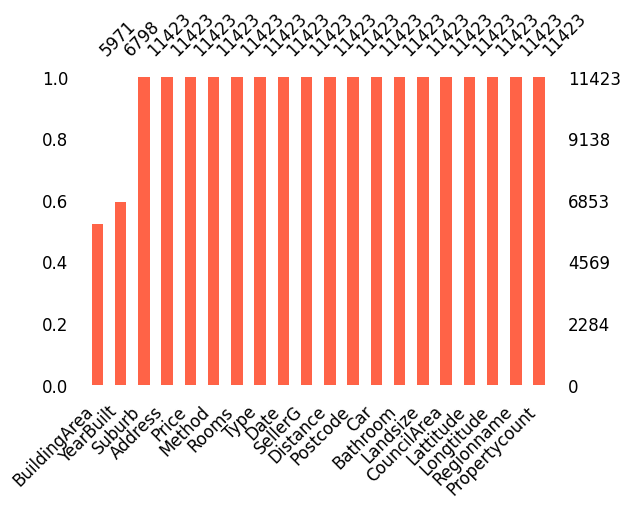

In [19]:
import missingno as msno
msno.bar(melb_df,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

###Análisis de Variables categóricas

Se verifican los tipos de datos asignados y se hacen las correcciones necesarias.

In [20]:
# Verificacion de types en las variables
melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


**Corrección de tipos de variables:**

Postcode se mantiene como entero para que el JOIN con la tabla de AirBnB funcione en SQL.

Propertycount, Car y Bathroom deben ser enteros

In [21]:
#Postcode se mantiene como entero
melb_df['Postcode'] = melb_df['Postcode'].astype(int)

# Propertycount, Car y Bathroom: son conteos, deben ser enteros
melb_df['Propertycount'] = melb_df['Propertycount'].astype(int)
melb_df['Car'] = melb_df['Car'].astype(int)
melb_df['Bathroom'] = melb_df['Bathroom'].astype(int)

melb_df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,int64


In [22]:
# Estudio la cardinalidad de cada columna categórica post-limpieza
categorical_variables = melb_df.select_dtypes(include='object').columns
for col in categorical_variables:
    print(f"{col}: {melb_df[col].nunique()} valores únicos")

Suburb: 309 valores únicos
Address: 11250 valores únicos
Type: 3 valores únicos
Method: 5 valores únicos
SellerG: 251 valores únicos
Date: 58 valores únicos
CouncilArea: 34 valores únicos
Regionname: 8 valores únicos


Date se convierte a formato datetime antes de ser guardada en la base de datos, cumpliendo con la validación de tipos requerida. Se conserva en el dataset junto con las variables derivadas SaleYear, SaleMonth, Semester, que facilitan el análisis temporal sin necesidad de operar sobre fechas completas en SQL.

In [23]:
# Conversión a datetime antes de guardar en SQL
melb_df['Date'] = pd.to_datetime(melb_df['Date'], dayfirst=True)

# Validación explícita del tipo
assert melb_df['Date'].dtype == 'datetime64[ns]', "Error: Date no es datetime"
print(f"✓ Date validado como: {melb_df['Date'].dtype}")

# Variables derivadas que complementan la información temporal
melb_df['SaleYear']  = melb_df['Date'].dt.year
melb_df['SaleMonth'] = melb_df['Date'].dt.month

✓ Date validado como: datetime64[ns]


In [24]:
# Cantidad de ventas realizadas agrupadas por mes y discriminadas por año
melb_df.groupby(['SaleYear', 'SaleMonth']).size()

SaleYear  SaleMonth
2016      1               2
          2              22
          4             254
          5             706
          6             569
          7             350
          8             562
          9             732
          10            441
          11            889
          12            494
2017      2             347
          3             547
          4             509
          5            1004
          6            1000
          7            1355
          8             773
          9             867
dtype: int64

Los registros disponibles datan desde enero de 2016 hasta noviembre de 2017. Considerando los 24 meses de ambos años, es posible crear una variable categórica con 4 valores únicos que abarquen un rango semestral cada una.



NOTA: En lugar de codificación OneHot, en este caso podríamos utilizar codificación ordinal asignando {2016_S1, 2016_S2, 2017_S1, 2017_S2} -> {1,2,3,4}.

In [25]:
# Función simple para la lógica semestral
def asignar_semestre(row):
    semestre = "S1" if row['SaleMonth'] <= 6 else "S2"
    return f"{row['SaleYear']}_{semestre}"

In [26]:
# Aplicamos la función para crear la variable categórica
melb_df['Semester'] = melb_df.apply(asignar_semestre, axis=1)

# Contar elementos por categoria
melb_df['Semester'].value_counts()

,count
Semester,
2016_S2,3468
2017_S1,3407
2017_S2,2995
2016_S1,1553


### Análisis descriptivo de variables numéricas

Se verifican y estudian estadísticas descriptivas para detectar anomalías.

In [27]:
# Estadísticas descriptivas de variables numéricas
numerical_col = melb_df.select_dtypes(include='number').columns
melb_df[numerical_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Rooms,11423.0,3.110216e+00,0.889452,1.00000,3.000000,3.0000,4.000000e+00,1.000000e+01
Price,11423.0,1.149468e+06,647675.909130,131000.00000,715000.000000,975000.0000,1.400000e+06,9.000000e+06
Distance,11423.0,1.082244e+01,5.873969,0.00000,7.000000,10.4000,1.360000e+01,4.740000e+01
Postcode,11423.0,3.104468e+03,94.026083,3000.00000,3044.000000,3082.0000,3.147000e+03,3.977000e+03
Bathroom,11423.0,1.582947e+00,0.695003,1.00000,1.000000,1.0000,2.000000e+00,8.000000e+00
Car,11423.0,1.694826e+00,0.989799,0.00000,1.000000,2.0000,2.000000e+00,1.000000e+01
Landsize,11423.0,5.207621e+02,343.757511,1.00000,269.000000,531.0000,6.700000e+02,3.448000e+03
BuildingArea,5971.0,1.564429e+02,126.796297,0.00000,105.000000,135.0000,1.840000e+02,6.791000e+03
YearBuilt,6798.0,1.961954e+03,38.066787,1196.00000,1937.000000,1965.0000,1.996000e+03,2.017000e+03
Lattitude,11423.0,-3.780653e+01,0.082947,-38.17488,-37.857235,-37.7960,-3.774950e+01,-3.740853e+01


In [28]:
# Seleccion de columnas numericas de interes
numerical_col = melb_df.select_dtypes(include='number').columns.tolist()

# Columnas que incluye numerical_col
print(numerical_col)

# Matriz con las columnas numericas
matrix_num = melb_df[numerical_col].values

# Mostrar contenido de la matriz numerica
print(matrix_num.shape)

['Rooms', 'Price', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'SaleYear', 'SaleMonth']
(11423, 14)


El enunciado pide validar tipos antes de guardar, se agrega la limpieza de Price para eliminar nulos y valores 0, que no tiene sentido una propiedad sin precio.

Se verifica que en Rooms no haya valores 0 o negativos.

In [29]:
#  Limpieza adicional

# Price: eliminar nulos y valores de 0
print(f"Filas con Price nulo: {melb_df['Price'].isna().sum()}")
print(f"Filas con Price = 0: {(melb_df['Price'] == 0).sum()}")
melb_df = melb_df[melb_df['Price'].notna() & (melb_df['Price'] > 0)]

# Rooms: verificar que no haya valores 0 o negativos
print(f"Filas con Rooms <= 0: {(melb_df['Rooms'] <= 0).sum()}")
melb_df = melb_df[melb_df['Rooms'] > 0]

print(f"\nShape final del dataset limpio: {melb_df.shape}")
melb_df.dtypes

Filas con Price nulo: 0
Filas con Price = 0: 0
Filas con Rooms <= 0: 0

Shape final del dataset limpio: (11423, 23)


,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,datetime64[ns]
Distance,float64
Postcode,int64


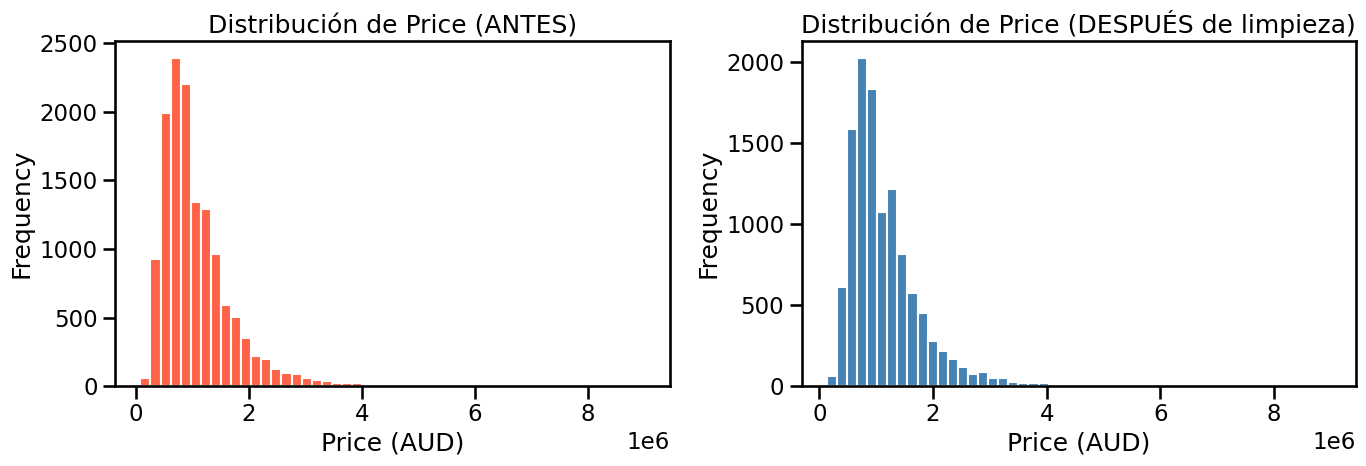

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes (con outliers, tomamos el df antes de filtrar Price)
melb_df_original['Price'].dropna().plot(
    kind='hist', bins=50, ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Distribución de Price (ANTES)')
axes[0].set_xlabel('Price (AUD)')

# Después
melb_df['Price'].plot(
    kind='hist', bins=50, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de Price (DESPUÉS de limpieza)')
axes[1].set_xlabel('Price (AUD)')

plt.tight_layout()
plt.show()

In [31]:
print(melb_df.columns)


Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize',
       'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude',
       'Regionname', 'Propertycount', 'SaleYear', 'SaleMonth', 'Semester'],
      dtype='object')


2. Generamos el dataset de AirnBnB agregado por zipcode.

Ingesta y validación de datos de Airnbnb, para que mantenga el mismo formato que Melbourne

In [32]:
import pandas as pd
from sqlalchemy import create_engine

In [33]:
# Paso 1: cargar todo
airbnb_df = pd.read_csv(
    'https://cs.famaf.unc.edu.ar/~mteruel/datasets/diplodatos/cleansed_listings_dec18.csv')

/tmp/ipykernel_4751/1702759730.py:2: DtypeWarning: Columns (35,77) have mixed types. Specify dtype option on import or set low_memory=False.
  airbnb_df = pd.read_csv(


In [34]:
# Paso 2: explorar
airbnb_df.info()
airbnb_df.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22895 entries, 0 to 22894
Data columns (total 84 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                22895 non-null  int64  
 1   listing_url                       22895 non-null  object 
 2   scrape_id                         22895 non-null  float64
 3   last_scraped                      22895 non-null  object 
 4   name                              22892 non-null  object 
 5   summary                           22199 non-null  object 
 6   space                             16844 non-null  object 
 7   description                       22563 non-null  object 
 8   neighborhood_overview             14424 non-null  object 
 9   notes                             11544 non-null  object 
 10  transit                           14943 non-null  object 
 11  access                            15168 non-null  object 
 12  inte

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,neighborhood_overview,notes,...,review_scores_location,review_scores_value,requires_license,license,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,9835,https://www.airbnb.com/rooms/9835,2.018120e+13,12/7/2018,Beautiful Room & House,NaN,"House: Clean, New, Modern, Quite, Safe. 10Km f...","House: Clean, New, Modern, Quite, Safe. 10Km f...",Very safe! Family oriented. Older age group.,NaN,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,1,0.04
1,10803,https://www.airbnb.com/rooms/10803,2.018120e+13,12/7/2018,Room in Cool Deco Apartment in Brunswick,A large air conditioned room with queen spring...,The apartment is Deco/Edwardian in style and h...,A large air conditioned room with queen spring...,This hip area is a crossroads between two grea...,NaN,...,9.0,9.0,f,NaN,t,moderate,t,t,1,1.50
2,12936,https://www.airbnb.com/rooms/12936,2.018120e+13,12/7/2018,St Kilda 1BR APT+BEACHSIDE+VIEWS+PARKING+WIFI+AC,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,FREE WiFi FREE in-building remote controlled g...,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,First floor apartment with both lift and stair...,...,9.0,9.0,f,NaN,f,strict_14_with_grace_period,f,f,17,0.15


In [35]:
# Paso 3: seleccionar columnas relevantes
interesting_cols = [
    'description', 'neighborhood_overview',
    'street', 'neighborhood', 'city', 'suburb', 'state', 'zipcode',
    'price', 'weekly_price', 'monthly_price',
    'latitude', 'longitude',
]
airbnb_df = airbnb_df[interesting_cols]

Justificación de la selección de columnas:

*   **zipcode**: para la unión con Postcode de Melbourne.
*   **price**: variable principal que representan el valor del vecindario, es la que se usa para claular el precio medio por zipcode.
*   **weekly_price, monthly_price**: complementan el análisis de precios del vecindario para estadías más largas.
*   **latitude, longitude**: permiten validar visualmente que ambos datasets cubren la misma zona geográfica
*   **suburb, neighborhood, city, state, street**: contexto geográfico, para entender que zipcodes corresponden a que zonas.
*   **description, neighborhood_overview**: parte de la exploración inicial

Limpieza de airbnb

In [36]:
# 1. Zipcode: viene como string con valores no numéricos
airbnb_df['zipcode'] = pd.to_numeric(airbnb_df['zipcode'], errors='coerce')
airbnb_df['zipcode'] = airbnb_df['zipcode'].fillna(0).astype(int)

# Ver cuántos quedaron en 0 (sin zipcode válido)
print(airbnb_df[airbnb_df['zipcode'] == 0].shape)

(146, 13)


In [37]:
# 2. Precios: vienen como string, se  convierte a float
for col in ['price', 'weekly_price', 'monthly_price']:
    airbnb_df[col] = airbnb_df[col].replace(r'[\$,]', '', regex=True).astype(float)

In [38]:
# 3. Verificar valores faltantes post-limpieza
airbnb_df[['zipcode', 'price', 'weekly_price', 'monthly_price']].isna().sum()

,0
zipcode,0
price,0
weekly_price,20371
monthly_price,21004


In [39]:
#Vemos cantidad de zipcodes y listings antes de agrupar
print(airbnb_df['zipcode'].nunique())
print(len(airbnb_df))

248
22895


In [40]:
# Exploramos Valores en común
intersection = np.intersect1d(
    airbnb_df['zipcode'].values, melb_df['Postcode'].values, assume_unique=False)

print("Airbnb unique zipcodes:", len(airbnb_df['zipcode'].unique()))
print("Sales unique zipcodes:", len(melb_df['Postcode'].unique()))
print("Common zipcodes:", len(intersection))

print('Registros en Melbourne con zipcode en Airbnb:',
      melb_df['Postcode'].isin(intersection).sum() / len(melb_df))
print('Registros en Airbnb con zipcode en Melbourne:',
      airbnb_df['zipcode'].isin(intersection).sum() / len(airbnb_df))

Airbnb unique zipcodes: 248
Sales unique zipcodes: 194
Common zipcodes: 188
Registros en Melbourne con zipcode en Airbnb: 0.9985993171671189
Registros en Airbnb con zipcode en Melbourne: 0.9029919196331077


In [41]:
# Exploración visual - distirbución georgáfica de ambos datasets
import plotly.express as px

# Melbourne
data = melb_df.sample(300, random_state=42)
fig = px.scatter_mapbox(
    data,
    lat='Lattitude',
    lon='Longtitude',
    color='SaleYear',
    zoom=9,
    height=500,
    mapbox_style='open-street-map',
    title='Muestra de propiedades Melbourne'
)
fig.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
fig.show()

# Airbnb — normalizar state primero
airbnb_df['state_clean'] = airbnb_df['state'].str.strip().str.upper()
airbnb_df['state_clean'] = airbnb_df['state_clean'].replace({
    'VI': 'VIC',
    'VICTORIA': 'VIC',
    '維多利亞 VIC': 'VIC'
})

data_airbnb = airbnb_df[airbnb_df['state_clean'].notna()].sample(300, random_state=42)
fig2 = px.scatter_mapbox(
    data_airbnb,
    lat='latitude',
    lon='longitude',
    color='state_clean',
    zoom=9,
    height=500,
    mapbox_style='open-street-map',
    title='Muestra de listings AirBnB — Melbourne'
)
fig2.update_layout(margin={"r": 0, "t": 50, "l": 0, "b": 0})
fig2.show()

En ambos mapas se pueden observar que ambos datasets cubren la misma zona geográfica.

Melbourne (ventas): el color muestra que las ventas de 2016 y 2017 están distirbuidos por toda la ciudad sin un patrón temporal.

Airbnb (listings): la distribución es más uniforme y cubre un área mayor que Melbourne. Hay mayor densidad en la zona centro lo cual es esperable por la mayor demanda de alquileres temporarios.

In [42]:
# 4. Agrupamos por zipcode
relevant_cols = ['price', 'weekly_price', 'monthly_price', 'zipcode']
airbnb_price_by_zipcode = airbnb_df[relevant_cols].groupby('zipcode')\
    .agg(
        airbnb_price_median=('price', 'median'),
        airbnb_record_count=('price', 'count'),
        airbnb_weekly_price_median=('weekly_price', 'median'),
        airbnb_monthly_price_median=('monthly_price', 'median')
    ).reset_index()

print(f"Dimensiones finales: {airbnb_price_by_zipcode.shape}")

Dimensiones finales: (248, 5)


In [43]:
# Creamos la base de datos SQL
engine = create_engine('sqlite:///melbourne.db', echo=False)

In [44]:
# Guardamos Melbourne curado
melb_df.to_sql('melbourne_housing', con=engine, if_exists='replace', index=False)

# Guardar Airbnb agrupado por zipcode
airbnb_price_by_zipcode.to_sql('airbnb_by_zipcode', con=engine, if_exists='replace', index=False)

248

In [45]:
# Verificamos que se cargaron correctamente
with engine.connect() as con:
    n_melb = pd.read_sql("SELECT COUNT(*) as total FROM melbourne_housing", con)
    n_airbnb = pd.read_sql("SELECT COUNT(*) as total FROM airbnb_by_zipcode", con)

print(f"Registros en melbourne_housing: {n_melb['total'].values[0]}")
print(f"Registros en airbnb_by_zipcode: {n_airbnb['total'].values[0]}")

assert n_melb['total'].values[0] == len(melb_df), "¡Error: filas no coinciden!"
assert n_airbnb['total'].values[0] == len(airbnb_price_by_zipcode), "¡Error: filas no coinciden!"
print("✓ Validación OK: los conteos coinciden con los DataFrames originales.")

Registros en melbourne_housing: 11423
Registros en airbnb_by_zipcode: 248
✓ Validación OK: los conteos coinciden con los DataFrames originales.


## 4. Consultas SQL

In [46]:
# Helper para ejecutar y mostrar resultados fácilmente
def run_query(query, engine):
    return pd.read_sql(query, con=engine)

### 4.1. Cantidad de registros por Regionname

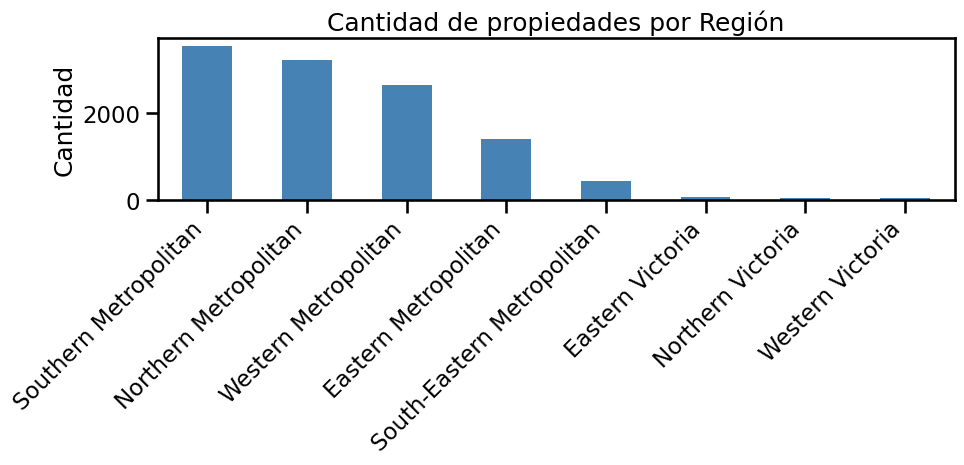

In [47]:
q1 = """
SELECT Regionname, COUNT(*) AS cantidad
FROM melbourne_housing
GROUP BY Regionname
ORDER BY cantidad DESC
"""
run_query(q1, engine)

#Gráfico q1
resultado_q1 = run_query(q1, engine)

resultado_q1.plot(kind='bar', x='Regionname', y='cantidad',
                  legend=False, color='steelblue', figsize=(10, 5))
plt.title('Cantidad de propiedades por Región')
plt.ylabel('Cantidad')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Análisis: Cantidad de propiedades por Región**

El gráfico muestra una distribución desigual entre las regiones de Melbourne. Las tres regiones metroplitanas con mayor cantidad de registros son Southern, Northern y Western Metropolitan, cada una con más de 2000 propiedades, lo que refleja la alta densidad residencial de estas zonas. Eastern Metropolitan tiene menor presencia, mientras que South-Eastern Metropolitan cae notablemente. Las tres regiones restantes, tienen una representación marginal en el dataset, porque corresponden a zonas periurbanas o rurales con menor actividad inmobiliaria registrada.

Las regiones con pocos registros van a tener estimaciones de precio promedio menos confiables, lo que justifica el uso de HAVING COUNT (*) >= 10 en la columna q5.



### 4.2. Cantidad de registros por Suburb y Regionname

,Suburb,Regionname,cantidad
0,Reservoir,Northern Metropolitan,335
1,Bentleigh East,Southern Metropolitan,239
2,Preston,Northern Metropolitan,226
3,Brunswick,Northern Metropolitan,184
4,Richmond,Northern Metropolitan,182
5,Essendon,Western Metropolitan,173
6,Coburg,Northern Metropolitan,168
7,Balwyn North,Southern Metropolitan,166
8,Glen Iris,Southern Metropolitan,164
9,Pascoe Vale,Northern Metropolitan,164


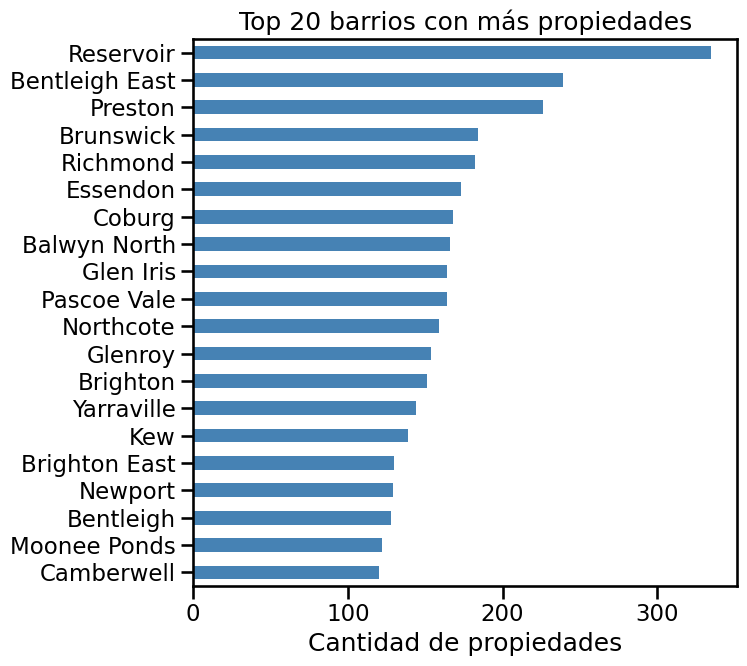

In [48]:
q2 = """
SELECT Suburb, Regionname, COUNT(*) AS cantidad
FROM melbourne_housing
GROUP BY Suburb, Regionname
ORDER BY cantidad DESC
LIMIT 20
"""
run_query(q2, engine)

# Tabla
resultado_q2 = run_query(q2, engine)
display(resultado_q2)

# Gráfico q2
resultado_q2 = run_query(q2, engine)

resultado_q2.plot(kind='barh', x='Suburb', y='cantidad',
                  color='steelblue', legend=False, figsize=(8, 7))
plt.title('Top 20 barrios con más propiedades')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Análisis: Top 20 barrios con más propiedades**
El gráfico muestra los 20 barrios con mayor cantidad de registros en el dataset. Reservoir presenta más de 300 propiedades. Geográficamente, la mayoría de estos barrios pertenecen a las regiones Nothern y Southern Metropolitan, lo cual es consistente con lo observado en q1, donde esas regiones concentraban la mayor cantidad de registros del dataset.

### 4.3. Propiedades por Regionname con más de 2 habitaciones

Se filtra por 'Rooms > 2'. Esta columna representa el número total de ambientes de la propiedad. Dado que 'Bedroom2' fue eliminada en la etapa de curación por inconsistencias con 'Rooms', se usa 'Rooms' como indicador del tamaño de la propiedad. Esta variable representa ambientes totales, no dormitorios, por lo que 'Rooms > 2' incluye propiedades donde al menos uno de los ambientes no es dormitorio (living, estudio, etc). Es una aproximación, en la que una propiedad con 2 habitaciones puede tener 3 o más ambientes.

,Regionname,propiedades_mas_2_rooms
0,Southern Metropolitan,2654
1,Northern Metropolitan,2268
2,Western Metropolitan,2183
3,Eastern Metropolitan,1200
4,South-Eastern Metropolitan,400
5,Eastern Victoria,46
6,Northern Victoria,34
7,Western Victoria,31


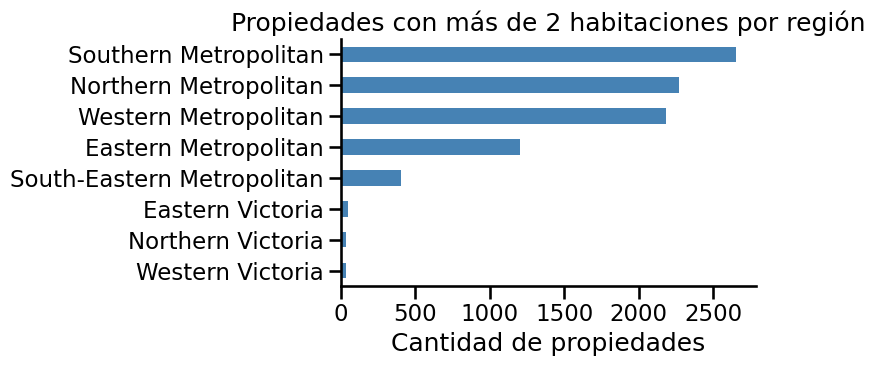

In [49]:
q3 = """
SELECT Regionname, COUNT(*) AS propiedades_mas_2_rooms
FROM melbourne_housing
WHERE Rooms > 2
GROUP BY Regionname
ORDER BY propiedades_mas_2_rooms DESC
"""

# Tabla
resultado_q3 = run_query(q3, engine)
display(resultado_q3)

# Gráfico
resultado_q3.plot(
    kind='barh', x='Regionname', y='propiedades_mas_2_rooms',
    color='steelblue', legend=False, figsize=(8, 4))

plt.title('Propiedades con más de 2 habitaciones por región')
plt.xlabel('Cantidad de propiedades')
plt.ylabel('')
plt.gca().invert_yaxis()
plt.spines = [plt.gca().spines[s].set_visible(False) for s in ['top', 'right']]
plt.tight_layout()
plt.show()

**Análisis: Propiedades con más de 2 habitaciones por región**

El patrón es similar al observado en q1, lo cual indica que la distribución de propiedades grandes sigue la misma lógica geográfica que la distribución general del dataset.
Southern, Northern y Western Metropolitan concentran la mayor cantidad de propiedades con más de 2 habitaciones.

La proporción de propiedades grandes respecto al total de cada región se mantiene constante, lo que sugiere que no hay una región que se especialice particularmente en propiedades chicas o grandes, sino que el tamaño de las propiedades se distribuye de forma homogénea en todo Melbourne.

### 4.4. Precio promedio por Type y Regionname

,Type,Regionname,precio_promedio
0,h,Eastern Metropolitan,1195188.0
1,t,Eastern Metropolitan,869769.0
2,u,Eastern Metropolitan,673574.0
3,h,Eastern Victoria,690000.0
4,u,Eastern Victoria,461333.0
5,h,Northern Metropolitan,1019696.0
6,t,Northern Metropolitan,734947.0
7,u,Northern Metropolitan,534581.0
8,h,Northern Victoria,564194.0
9,h,South-Eastern Metropolitan,956267.0


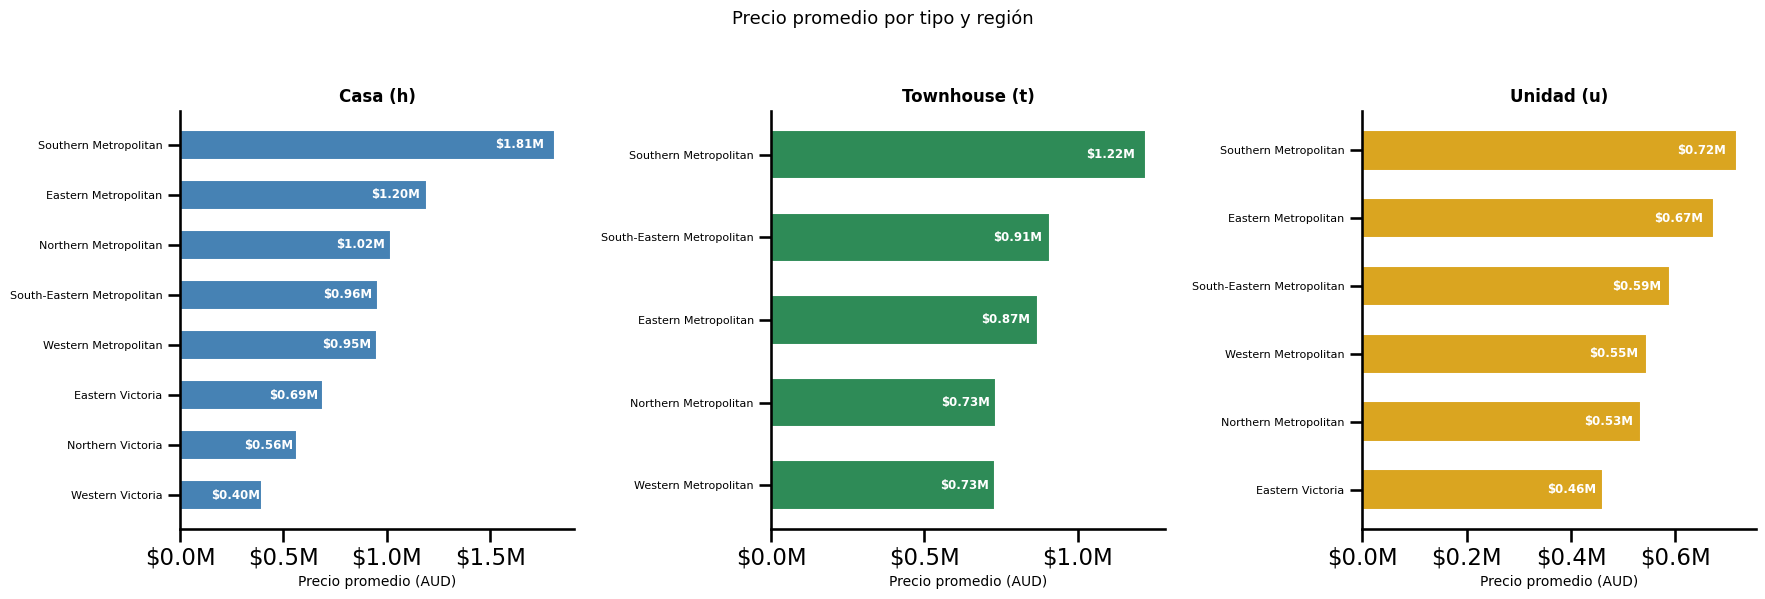

In [50]:
q4 = """
SELECT Type, Regionname, ROUND(AVG(Price), 0) AS precio_promedio
FROM melbourne_housing
GROUP BY Type, Regionname
ORDER BY Regionname, precio_promedio DESC
"""

resultado_q4 = run_query(q4, engine)
display(resultado_q4)

# Formateador definido una sola vez, fuera del loop
millon_fmt = plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # más ancho, sin sharey

tipos  = {'h': 'Casa (h)', 't': 'Townhouse (t)', 'u': 'Unidad (u)'}
colores = {'h': 'steelblue', 't': 'seagreen', 'u': 'goldenrod'}

for ax, (tipo, label) in zip(axes, tipos.items()):
    subset = (resultado_q4[resultado_q4['Type'] == tipo]
              .sort_values('precio_promedio', ascending=True))

    bars = ax.barh(subset['Regionname'], subset['precio_promedio'],
                   color=colores[tipo], edgecolor='white', height=0.6)

    # Etiqueta dentro de la barra, pegada al borde derecho
    for bar, val in zip(bars, subset['precio_promedio']):
        ax.text(
            bar.get_width() * 0.97,          # 97% del ancho → adentro
            bar.get_y() + bar.get_height() / 2,
            f'${val/1e6:.2f}M',
            va='center', ha='right',
            fontsize=8.5, color='white', fontweight='bold'
        )

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Precio promedio (AUD)', fontsize=10)
    ax.xaxis.set_major_formatter(millon_fmt)
    ax.tick_params(axis='y', labelsize=8)    # regiones más chicas
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Precio promedio por tipo y región', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Análisis: Precio promedio por Tipo y Región**

Southern Metropolitan lidera en los tres tipos, con un precio elevado que se mantiene independientemente del tipo de propiedad. Las casas muestran la mayor dispersión entre regiones, mientras que las unidades son el mercado más homogéneo. Las regiones Victoria solo aparecen en casas, con los precios más bajos.




### 4.5. Top 5 barrios (Suburb) con propiedades más caras en promedio


,Suburb,precio_promedio,cantidad
0,Canterbury,2294347.0,49
1,Malvern,2287286.0,42
2,Middle Park,2225935.0,31
3,Toorak,2191061.0,49
4,Brighton,2095224.0,151


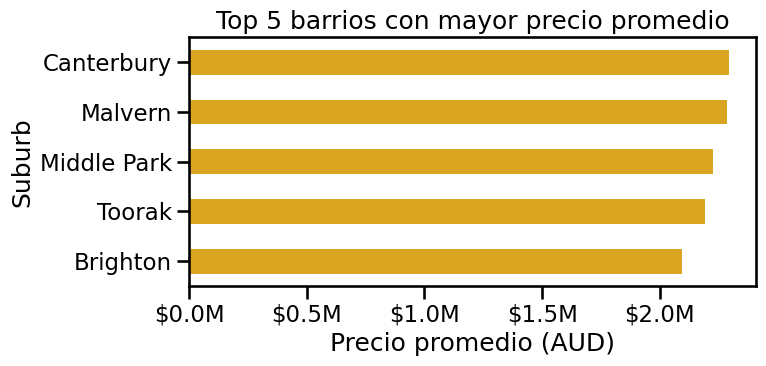

In [51]:
q5 = """
SELECT Suburb, ROUND(AVG(Price), 0) AS precio_promedio, COUNT(*) AS cantidad
FROM melbourne_housing
GROUP BY Suburb
HAVING COUNT(*) >= 10        -- mínimo de registros para que el promedio sea confiable
ORDER BY precio_promedio DESC
LIMIT 5
"""
run_query(q5, engine)

# Tabla
resultado_q5 = run_query(q5, engine)
display(resultado_q5)

#Gráfico q5
resultado_q5.plot(kind='barh', x='Suburb', y='precio_promedio',
                  legend=False, color='goldenrod', figsize=(8, 4))
plt.title('Top 5 barrios con mayor precio promedio')
plt.xlabel('Precio promedio (AUD)')
plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()


**Análisis: Top 5 barrios con mayor precio promedio**

Los cinco barrios más caros de MElbourne son Canterbury, Malvern, Middle Park, Toorak y Brighton, todos los precios promedio superiores a $2M AUD. La diferencia entre ellos es pequeña, loq ue sugiere que forman un grupo homogéneo de barrios de alto poder adquisitivo.




Vale destacar el uso de 'HAVING COUNT(*)>=10', que permitió que el ranking sea representativo: Brighton tiene 151 propiedades registradas, lo que hace que su promedio de $2.1M sea estadísticamente confiable. Sin ese filtro, barrios con 1 o 2 ventas de propiedades muy caran podrían aparecer.
Geográficamente estos barrios pertenecen todos a la región Southern Metropolitan, lo cual es consistente con lo observado en q4, donde esa región mostraba precios promedio aun más altos para casas y townhouses.


In [52]:
top5_suburbs = resultado_q5['Suburb'].tolist()
data_top5 = melb_df[melb_df['Suburb'].isin(top5_suburbs)]

fig = px.scatter_mapbox(
    data_top5,
    lat="Lattitude",
    lon="Longtitude",
    color="Suburb",
    size="Price",
    size_max=25,
    opacity=0.7,
    hover_name="Address",
    hover_data={"Price": True, "Rooms": True, "Type": True},
    zoom=9,
    height=700,
    mapbox_style="open-street-map",
    title="Top 5 barrios más caros — distribución geográfica"
)

fig.update_layout(
    margin={"r": 0, "t": 50, "l": 0, "b": 0},
    mapbox_bounds={
        "west": data_top5.Longtitude.min() - 0.1,
        "east": data_top5.Longtitude.max() + 0.1,
        "south": data_top5.Lattitude.min() - 0.1,
        "north": data_top5.Lattitude.max() + 0.1
    }
)

fig.show()

## 5. Join entre tablas


Antes de combinar, verificamos el contenido de ambas tablas ingestadas.

In [53]:
# Vista previa de la tabla de Melbourne Housing
print("=== melbourne_housing ===")
display(run_query("SELECT * FROM melbourne_housing LIMIT 3", engine))

# Vista previa de la tabla de AirBnB
print("=== airbnb_by_zipcode ===")
display(run_query("SELECT * FROM airbnb_by_zipcode LIMIT 3", engine))

=== melbourne_housing ===


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,SaleYear,SaleMonth,Semester
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03 00:00:00.000000,2.5,3067,...,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,2016,12,2016_S2
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04 00:00:00.000000,2.5,3067,...,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019,2016,2,2016_S1
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04 00:00:00.000000,2.5,3067,...,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019,2017,3,2017_S1


=== airbnb_by_zipcode ===


,zipcode,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,0,120.0,146,780.0,3300.0
1,2010,40.0,1,NaN,NaN
2,2134,50.0,1,NaN,NaN


El objetivo del JOIN entre tablas es combinar ambas tablas usando el Postcode de Melbourne y zipcode de Airbnb para la unión. Se utiliza Left Join para conservar todas las propiedades de Melbourne aunque no tengan correspondencia en Airbnb.

El resultado es un dataset donde cada propiedad de Melbourne hereda el precio promedio de Airbnb de su zipcode, lo que permite analizar si el mercado de alquileres tempoerarios tiene relación con el valor de sus propiedades.

In [54]:
q_join = """
SELECT
    m.Suburb,
    m.Postcode,
    m.Regionname,
    m.Type,
    m.Rooms,
    m.Price,
    a.airbnb_price_median,
    a.airbnb_record_count,
    a.airbnb_weekly_price_median,
    a.airbnb_monthly_price_median
FROM melbourne_housing m
LEFT JOIN airbnb_by_zipcode a
    ON m.Postcode = a.zipcode
"""
merged_sql_df = run_query(q_join, engine)
print(merged_sql_df.shape)
merged_sql_df.head()

(11423, 10)


,Suburb,Postcode,Regionname,Type,Rooms,Price,airbnb_price_median,airbnb_record_count,airbnb_weekly_price_median,airbnb_monthly_price_median
0,Abbotsford,3067,Northern Metropolitan,h,2,1480000.0,100.0,258.0,380.0,1440.0
1,Abbotsford,3067,Northern Metropolitan,h,2,1035000.0,100.0,258.0,380.0,1440.0
2,Abbotsford,3067,Northern Metropolitan,h,3,1465000.0,100.0,258.0,380.0,1440.0
3,Abbotsford,3067,Northern Metropolitan,h,3,850000.0,100.0,258.0,380.0,1440.0
4,Abbotsford,3067,Northern Metropolitan,h,4,1600000.0,100.0,258.0,380.0,1440.0


El resultado tiene las mismas 11.423 filas que Melnourne con las columnas de Airbnb agregadas.

## 6. Validación posterior

Se verifican cuatro condiciones para garantizar que el JOIN fue correcto:
1. Filas conservadas: el left join no debe agregar ni perder filas respecto a Melbourne original.

2. Nulos inesperados: las columnas de Melbourne no deben tener nulos nuevos introducidos por el JOIN.

3. Rango de precios de Melbourne: los precios deben mantenerse dentro del rango del dataset original.

4. Precios Airbnb: los valores agregados desde Airbnb deben ser positivos y estar en un rango razonable para el mercado de Melbourne.

In [55]:
# 1. El número de filas no debe cambiar
assert len(merged_sql_df) == len(melb_df), \
    f"Error: filas esperadas {len(melb_df)}, obtenidas {len(merged_sql_df)}"

# 2. Las columnas originales no deben tener nulos nuevos
for col in ['Suburb', 'Price', 'Rooms', 'Regionname']:
    n_nulls = merged_sql_df[col].isna().sum()
    assert n_nulls == 0, f"Error: columna '{col}' tiene {n_nulls} nulos inesperados"

# 3. Rango razonable de precio
assert merged_sql_df['Price'].min() > 0, "Hay precios negativos o cero"
assert merged_sql_df['Price'].max() <= melb_df['Price'].max(), \
    "Hay precios que superan el máximo del dataset original"

# 4. Cobertura del JOIN
cobertura = merged_sql_df['airbnb_price_median'].notna().mean()

# 5. Rango de precios AirBnB
precio_airbnb_valido = merged_sql_df['airbnb_price_median'].dropna()
assert precio_airbnb_valido.min() > 0, "Hay precios AirBnB negativos"

print(f"✓ Todas las validaciones pasaron.")
print(f"  Filas en resultado: {len(merged_sql_df)}")
print(f"  Cobertura del JOIN (propiedades con info AirBnB): {cobertura:.1%}")
print(f"  Rango airbnb_price_median: ${precio_airbnb_valido.min():.0f} — ${precio_airbnb_valido.max():.0f}")

✓ Todas las validaciones pasaron.
  Filas en resultado: 11423
  Cobertura del JOIN (propiedades con info AirBnB): 99.9%
  Rango airbnb_price_median: $38 — $289


A continuación, se realiza el análisis de cobertura del JOIN, que sirve para entender cuántas propiedades de Melbourne tienen información de AirBnB disponible en su código postal.

El análisis responde ¿qué porcentaje de las propiedades quedaron sin precio Airbnbn de referencia tras el JOIN? Es importante porque si la cobertura fuera muy baja, cualquier análisis posterior que cruce precio de venta con precio de Airbnbn sería poco representativo del mercado total.

Propiedades con info AirBnB:  11407 (99.9%)
Propiedades sin info AirBnB:  16 (0.1%)
Zipcodes sin match: [np.int64(3022), np.int64(3061), np.int64(3340), np.int64(3431), np.int64(3437), np.int64(3756)]


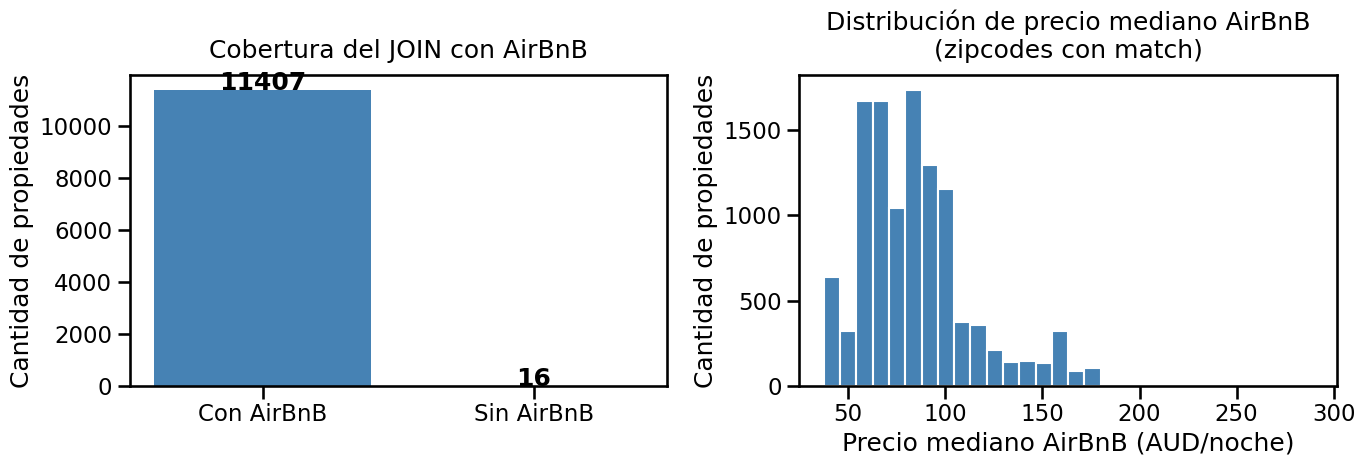

In [56]:
# Análisis de cobertura del JOIN
sin_match = merged_sql_df[merged_sql_df['airbnb_price_median'].isna()]
con_match = merged_sql_df[merged_sql_df['airbnb_price_median'].notna()]

print(f"Propiedades con info AirBnB:  {len(con_match)} ({len(con_match)/len(merged_sql_df)*100:.1f}%)")
print(f"Propiedades sin info AirBnB:  {len(sin_match)} ({len(sin_match)/len(merged_sql_df)*100:.1f}%)")
print(f"Zipcodes sin match: {sorted(sin_match['Postcode'].astype(int).unique())}")

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izq: cobertura
axes[0].bar(['Con AirBnB', 'Sin AirBnB'],
            [len(con_match), len(sin_match)],
            color=['steelblue', 'lightgray'])
axes[0].set_title('Cobertura del JOIN con AirBnB', pad=12)
axes[0].set_ylabel('Cantidad de propiedades')
for i, v in enumerate([len(con_match), len(sin_match)]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Der: distribución de airbnb_price_median
axes[1].hist(con_match['airbnb_price_median'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución de precio mediano AirBnB\n(zipcodes con match)', pad=12)
axes[1].set_xlabel('Precio mediano AirBnB (AUD/noche)')
axes[1].set_ylabel('Cantidad de propiedades')

plt.subplots_adjust(wspace=0.35)
plt.tight_layout()
plt.show()

En el gráfico izquierdo se observa la cobertura del JOIN, en la que muestra la validación: 11407 propiedades obtuvieron información de Airbnb contra 16 sin match. Como la diferencia es grande, el JOIN puede considerarse casi completo para fines prácticos.

El gráfico derecho, muestra la ditribución de precio medio AirBnB, la mayoría de los zipcodes tienen un precio medio entre 100 y 200 AUD por noche, con una distribución sesgada hacia la derecha. Los casos por encima de 400 AUD son tan pocos que apenas se distinguen en el gráfico.

## Ejercicio 2 - Pandas:

Este ejercicio usa el archivo `airbnb_price_by_zipcode.csv` generado en el notebook `02.1 Combinación de datasets.ipynb`. Si no lo tenés, generarlo primero antes de comenzar esta parte.

1. Seleccionar un subconjunto de columnas que les parezcan relevantes al problema de predicción del valor de la propiedad. Justificar explicitamente las columnas seleccionadas y las que no lo fueron.
  1. Valores faltantes: ¿Qué porcentaje de filas tienen al menos un valor faltante?
  2. Mostrar la dispersión o distribución de las columnas seleccionadas.
 3. Eliminar los valores extremos que no sean relevantes para la predicción de valores de las propiedades.
 4. Mostrar visualmente los valores extremos que eliminás


2. Agregar información adicional respectiva al entorno de una propiedad a partir del [conjunto de datos de AirBnB](https://www.kaggle.com/tylerx/melbourne-airbnb-open-data?select=cleansed_listings_dec18.csv) utilizado en el práctico.
  1. Seleccionar qué variables agregar y qué combinaciones aplicar a cada una. Por ejemplo, pueden utilizar solo la columna `price`, o aplicar múltiples transformaciones como la mediana (¿por qué no la media?) o el mínimo.
  2. Utilizar la variable zipcode para unir los conjuntos de datos. Sólo incluir los zipcodes que tengan una cantidad mínima de registros (a elección) como para que la información agregada sea relevante.
  3. Mostrar un gráfico zipcode vs airbnb_price_median.
  4. Investigar al menos otras 2 variables que puedan servir para combinar los datos, y justificar si serían adecuadas o no. Pueden asumir que cuentan con la ayuda de anotadores expertos para encontrar equivalencias entre barrios o direcciones, o que cuentan con algoritmos para encontrar las n ubicaciones más cercanas a una propiedad a partir de sus coordenadas geográficas. **NO** es necesario que realicen la implementación. Si tuvieras que entrevistar a un experto inmobiliario para mapear barrios entre datasets, ¿qué 3 preguntas le harías para validar esa correspondencia?
  5. Si las coordenadas geoespaciales estuvieran disponibles, como las usarian?

Pueden leer otras columnas del conjunto de AirBnB además de las que están en `interesting_cols`, si les parecen relevantes.

¿Qué cosas no están en los datos que te gustaría tener para predecir mejor el precio de una propiedad?


### Criterios de evaluación
Se evaluará principalmente:
- claridad del código,
- justificación de las decisiones de curación,
- coherencia entre el análisis realizado y las conclusiones,
- presencia de validaciones después de operaciones críticas como merges o cargas a base.

No se espera una única solución correcta, pero sí que las decisiones estén justificadas y sean consistentes con los datos.


# Resolución Ej 2

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
assert 'airbnb_price_by_zipcode' in dir(), "Ejecutá primero el Ej 1"
assert 'airbnb_df' in dir(), "Ejecutá primero el Ej 1"

print(f"✓ airbnb_price_by_zipcode: {airbnb_price_by_zipcode.shape}")
print(f"✓ airbnb_df: {airbnb_df.shape}")

✓ airbnb_price_by_zipcode: (248, 5)
✓ airbnb_df: (22895, 14)


### 2.1 Selección de columnas relevantes

Se seleccionará las siguiente columnas relevantes:

*   'Rooms', 'Type', 'Bathroom', 'Car', 'Landsize': características físicas directas de la propiedad.
*   'Price': variable de interés.
*   'Distance', 'Postcode', 'Regionname', 'Suburb': ubicación
*   'SaleYear', 'SaleMonth', 'Semester': contexto temporal.




In [59]:
# Columnas seleccionadas para predicción de precio
columnas_seleccionadas = [
    'Rooms',
    'Type',
    'Price',
    'Distance',
    'Postcode',
    'Bathroom',
    'Car',
    'Landsize',
    'Regionname',
    'Suburb',
    'Lattitude',
    'Longtitude',
    'SaleYear',
    'SaleMonth',
    'Semester',
]

**Columnas excluidas:**
*   'BuildingArea', 'YearBuilt': eliminadas en el Ej 1 por alto porcetaje de nulos.
*   Address: identificador único, no aporta al modelo.
*   Method: describe el proceso de venta, no una característica de la propiedad.
*   SellerG: identifica a la inmobiliaria vendedora, no es característica de las propiedades.
*   CouncilArea: redundante con Suburb/Regionname.
*  Propertycount: característica del suburbio, no de la propiedad individual.
*   'Date': reemplazada por las variables, derivadas de 'SaleYear', 'SaleMonth', 'Semester'.











In [60]:
melb_ej2 = melb_df[columnas_seleccionadas].copy()
print(melb_ej2.shape)
melb_ej2.head(3)

(11423, 15)


,Rooms,Type,Price,Distance,Postcode,Bathroom,Car,Landsize,Regionname,Suburb,Lattitude,Longtitude,SaleYear,SaleMonth,Semester
0,2,h,1480000.0,2.5,3067,1,1,202.0,Northern Metropolitan,Abbotsford,-37.7996,144.9984,2016,12,2016_S2
1,2,h,1035000.0,2.5,3067,1,0,156.0,Northern Metropolitan,Abbotsford,-37.8079,144.9934,2016,2,2016_S1
2,3,h,1465000.0,2.5,3067,2,0,134.0,Northern Metropolitan,Abbotsford,-37.8093,144.9944,2017,3,2017_S1


### 2.2. % de filas con al menos un valor faltante


In [61]:
filas_con_nulos = melb_ej2.isnull().any(axis=1).sum()
total = len(melb_ej2)
print(f"Filas con al menos un nulo: {filas_con_nulos} ({filas_con_nulos/total:.1%})")

# Detalle por columna
print("\nNulos por columna:")
print(melb_ej2.isnull().sum().sort_values(ascending=False))
filas_con_nulos = melb_ej2.isnull().any(axis=1).sum()
total = len(melb_ej2)
pct = filas_con_nulos / total

print(f"Filas con al menos un nulo: {filas_con_nulos} ({pct:.1%})")
print(f"\nNulos por columna:")
print(melb_ej2.isnull().sum()[melb_ej2.isnull().sum() > 0].sort_values(ascending=False))

Filas con al menos un nulo: 0 (0.0%)

Nulos por columna:
Rooms         0
Type          0
Price         0
Distance      0
Postcode      0
Bathroom      0
Car           0
Landsize      0
Regionname    0
Suburb        0
Lattitude     0
Longtitude    0
SaleYear      0
SaleMonth     0
Semester      0
dtype: int64
Filas con al menos un nulo: 0 (0.0%)

Nulos por columna:
Series([], dtype: int64)


El dataset no presenta valores faltantes. Esto es consecuencia directa de la curación realizada en el Ej 1, donde se eliminaron filas con nulos en variables como 'Car', 'Bathroom', 'Price' y 'Landsize', y se excluyeron columnas con alta proporción de faltantes como 'BuildingArea' y 'YearBuilt'.

### 2.3. Distribución de columnas seleccionadas

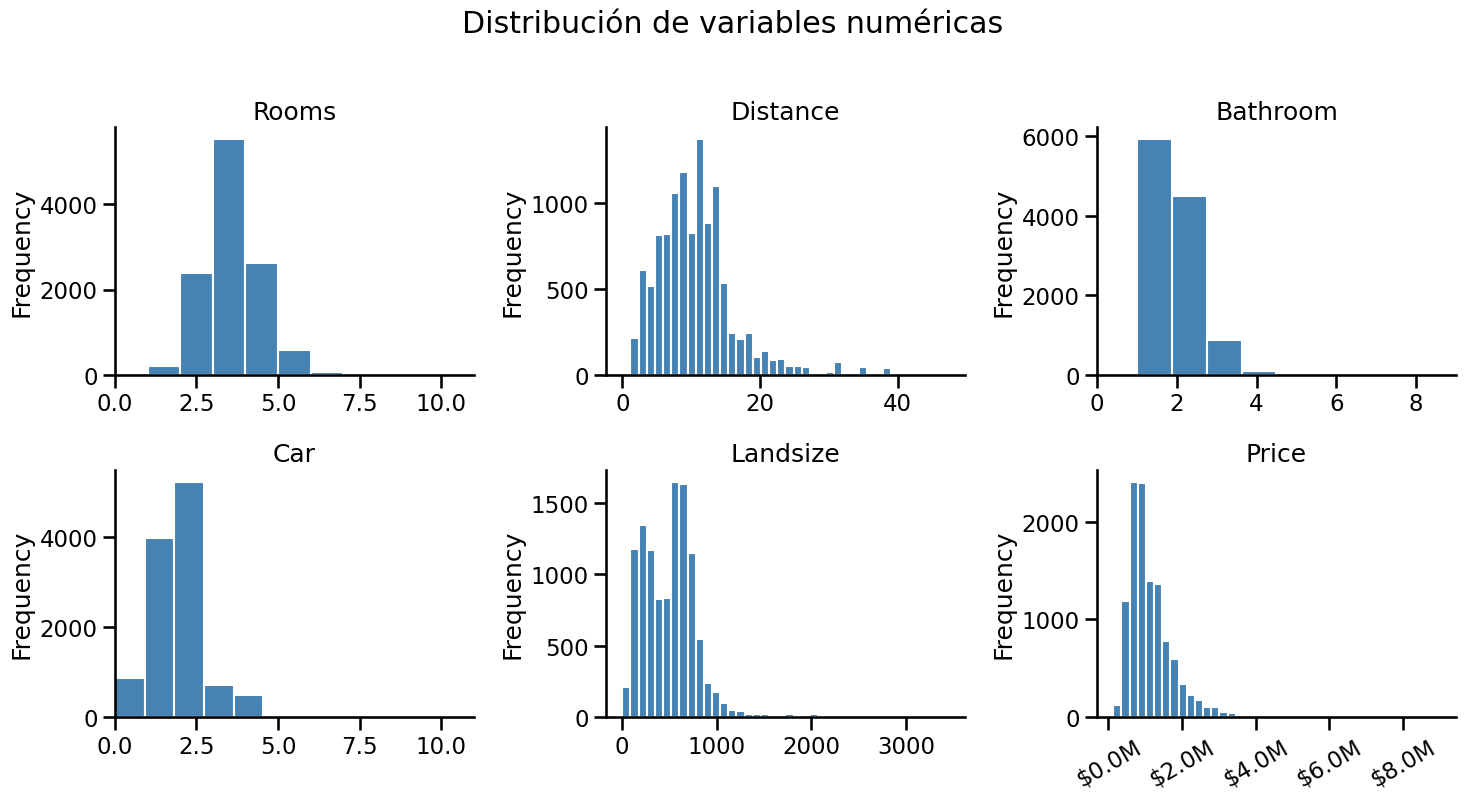

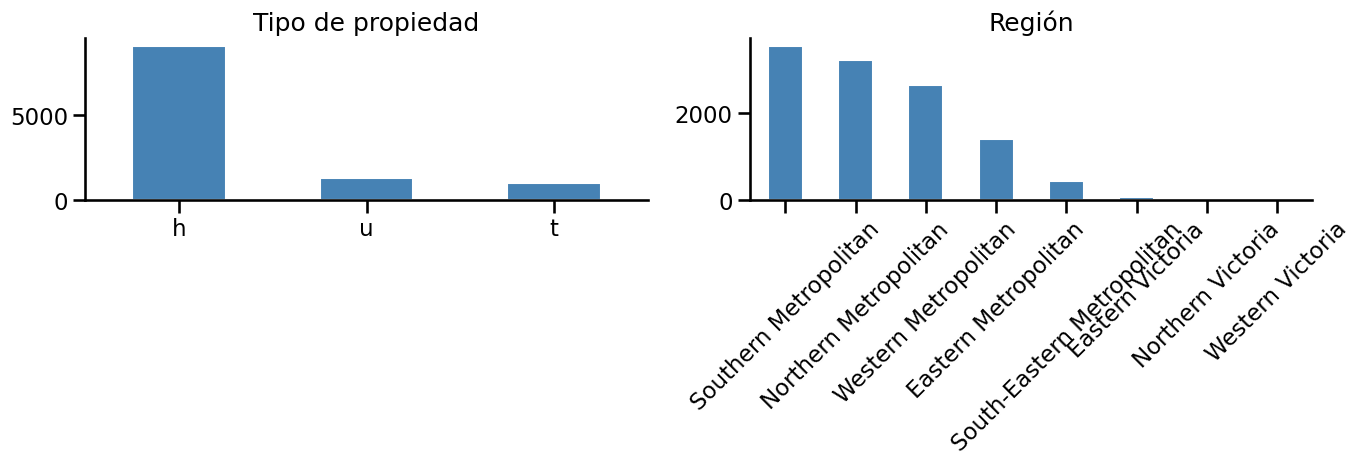

In [62]:
#Distribución de columnas seleccionadas

melb_ej2['Car'] = melb_ej2['Car'].astype(int)
melb_ej2['Bathroom'] = melb_ej2['Bathroom'].astype(int)
melb_ej2['Rooms'] = melb_ej2['Rooms'].astype(int)

num_cols = ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Price']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    n_unique = melb_ej2[col].nunique()
    bins = min(n_unique, 40)

    melb_ej2[col].plot(kind='hist', bins=bins, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.spines[['top', 'right']].set_visible(False)


    if col in ['Rooms', 'Bathroom', 'Car']:
        ax.set_xlim(0, melb_ej2[col].max() + 1)

    if col == 'Price':
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
        ax.tick_params(axis='x', rotation=30)

plt.suptitle('Distribución de variables numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Categóricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

melb_ej2['Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Tipo de propiedad')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines[['top', 'right']].set_visible(False)

melb_ej2['Regionname'].value_counts().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Región')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Análisis de distribuciones:**

- **Rooms**: distribución concentrada en 2-4 ambientes, con muy pocas propiedades de 6 o más. El mercado está dominado por propiedades medianas.
- **Distance**: distribución aproximadamente normal centrada entre 5-15 km del CBD. Pocas propiedades a más de 30 km.
- **Bathroom**: la gran mayoría de las propiedades tiene 1-2 baños. Valores mayores a 3 son menos frecuentes.
- **Car**: concentrado en 1-2 cocheras. La presencia de propiedades sin cochera es menor pero visible.
- **Landsize**: distribución sesgada a la derecha con la mayoría de propiedades de 200 - 800 m². Los valores extremos ya fueron tratados en el Ej 1 con el percentil 99.
- **Price**: distribución sesgada a la derecha con la mayoría de propiedades entre 500K y 1.5M AUD. La cola derecha refleja propiedades de lujo, lo que justifica el uso de la mediana como medida de tendencia central en lugar de la media.
- **Tipo de propiedad**: las casas (h) dominan ampliamente, seguidas de unidades (u)  y townhouses (t) con mucha menor frecuencia.
- **Región**: Southern, Northern y Western Metropolitan concentran la mayor parte de las propiedades. Las regiones Victoria tienen muy pocos registros.

Los boxplots permiten identificar visualmente que variables tienen valores extremos y en qué magnitud, antes de decidir como tratarlos, se procede a graficarlos.  

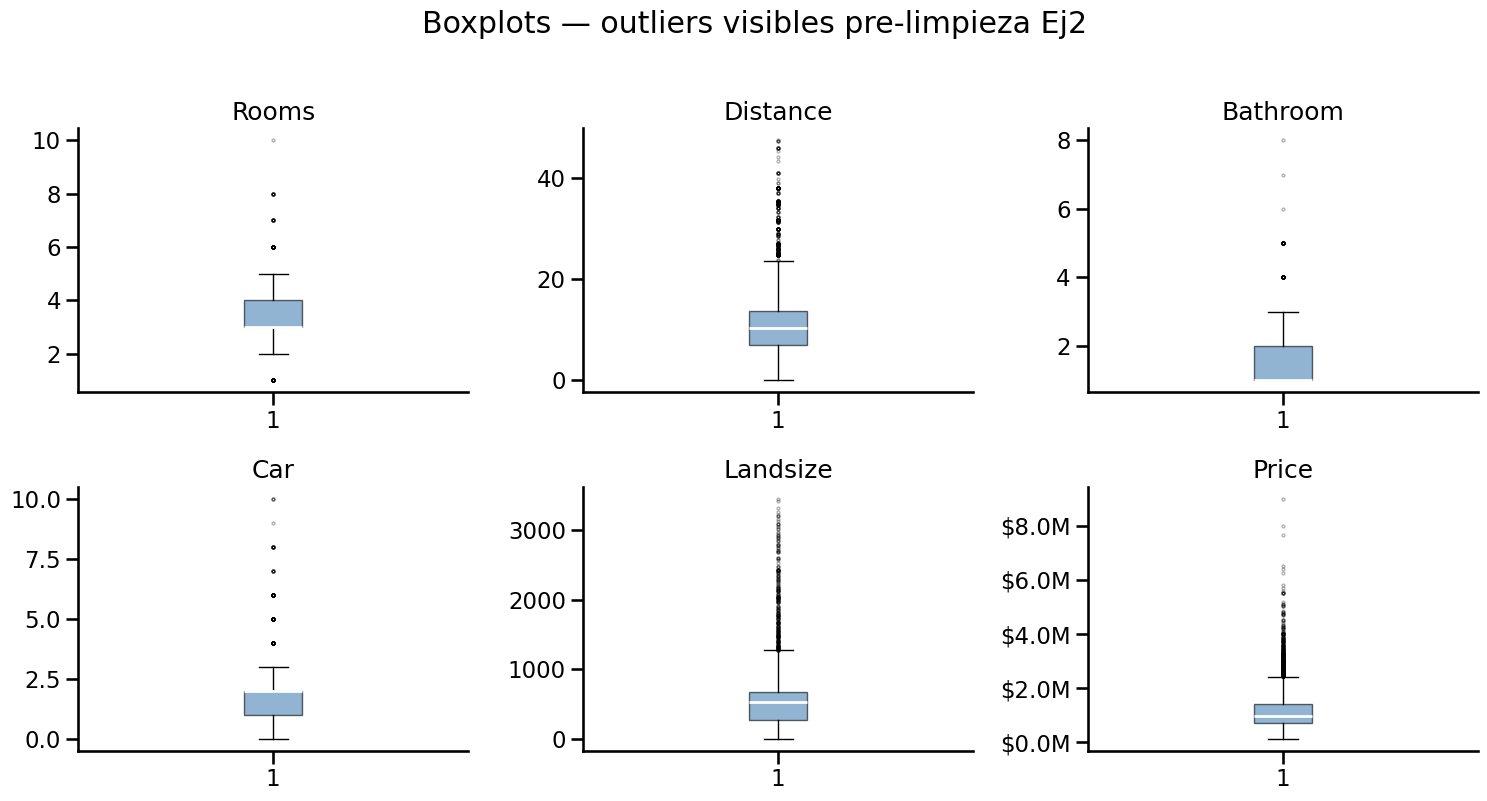

In [63]:
#Análisis de outliers eliminados

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flatten(), num_cols):
    ax.boxplot(melb_ej2[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='white', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3, color='steelblue'))
    ax.set_title(col)
    ax.set_xlabel('')
    ax.spines[['top', 'right']].set_visible(False)

    if col == 'Price':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Boxplots — outliers visibles pre-limpieza Ej2', y=1.01)
plt.tight_layout()
plt.show()

Se observa que:

- **Landsize** y **Price**: tienen colas derechas largas con outliers extremos que pueden distorsionar el entrenamiento de un modelo predictivo.

- **Distance**: presenta outliers hacia valores altos (mayores a 30 km), que correpsonden a propiedades muy alejadas del CBD, poco representativas del mercado metropolitano.

- **Rooms**, **Bathroom** y **Car**: tienen outlieras puntuales que son casos atípicos y no representan el mercado feneral.

A partir de este análisis se decide qué umbrales aplicar.

### 2.4. Eliminar valores extremos

Para variables continuas con distribución sesgada (Price, Landsize, Distance) se aplica un corte en el percentil 99, eliminando el 1% más extremo sin asumir un umbral fijo. Para variables discretas (Rooms, Bathroom, Car) se usan umbrales fijos basados en el dominio: una propiedades con más de 6 ambientes, 4 baños o 6 cocheras es un caso atípico que no representa el mercado residencial general de Melbourne.

In [64]:
#Para ver cuanto aporta cada variable al total eliminado
melb_antes_outliers = len(melb_ej2)

limites = {
    'Price':    melb_ej2['Price'].quantile(0.99),
    'Landsize': melb_ej2['Landsize'].quantile(0.99),
    'Distance': melb_ej2['Distance'].quantile(0.99),
    'Rooms':    6,
    'Bathroom': 4,
    'Car':      6,
}

for col, umbral in limites.items():
    n = (melb_ej2[col] > umbral).sum()
    print(f"{col}: {n} filas sobre el umbral ({n/melb_antes_outliers:.1%})")

Price: 114 filas sobre el umbral (1.0%)
Landsize: 115 filas sobre el umbral (1.0%)
Distance: 113 filas sobre el umbral (1.0%)
Rooms: 18 filas sobre el umbral (0.2%)
Bathroom: 28 filas sobre el umbral (0.2%)
Car: 19 filas sobre el umbral (0.2%)


In [65]:
# Guardamos el df antes para comparar visualmente
melb_ej2_original = melb_ej2.copy()

## 2.4 Eliminación de outliers

melb_antes_outliers = len(melb_ej2)

# Umbrales por percentil 99 para variables con cola larga
for col in ['Price', 'Landsize', 'Distance']:
    q99 = melb_ej2[col].quantile(0.99)
    melb_ej2 = melb_ej2[melb_ej2[col] <= q99]

# Umbrales fijos para variables discretas con valores imposibles
melb_ej2 = melb_ej2[melb_ej2['Rooms'] <= 6]
melb_ej2 = melb_ej2[melb_ej2['Bathroom'] <= 4]
melb_ej2 = melb_ej2[melb_ej2['Car'] <= 6]

filas_eliminadas = melb_antes_outliers - len(melb_ej2)
print(f"Filas eliminadas: {filas_eliminadas} ({filas_eliminadas/melb_antes_outliers:.1%})")
print(f"Shape final: {melb_ej2.shape}")

Filas eliminadas: 390 (3.4%)
Shape final: (11033, 15)


Se eliminó el 3.4% de las filas (390 registros), correspondiente a valores extremos en Price, Landsize, Distance. Los umbrales fijos para Rooms, Bathroom y Car no eliminaron ninguna fila adiciona, ya que la limpieza del Ej 1 había acotado esas variables.

### 2.5. Visualizar los outliers eliminados

Se grafican boxplots comparativos, antes de la limpieza y después, para las tres variables donde se detectaron outliers: Price, Landsize y Distance.

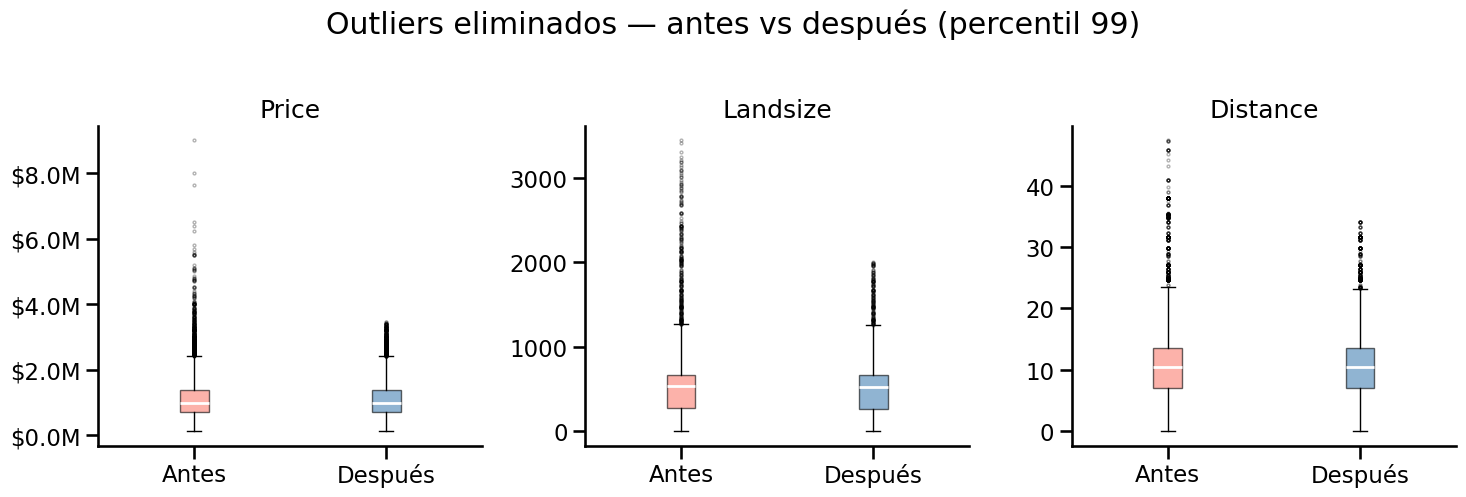

In [68]:
## 2.5 Visualización de outliers eliminados

# Reconstruimos el dataset Pre-limpieza de outliers para comparar
melb_pre = melb_df[columnas_seleccionadas].copy()
melb_pre['Car'] = melb_pre['Car'].astype(int)
melb_pre['Bathroom'] = melb_pre['Bathroom'].astype(int)
melb_pre['Rooms'] = melb_pre['Rooms'].astype(int)

cols_outliers = ['Price', 'Landsize', 'Distance']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols_outliers):
    bp = ax.boxplot(
        [melb_pre[col], melb_ej2[col]],
        tick_labels=['Antes', 'Después'],  # fix warning
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor('salmon')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('steelblue')
    bp['boxes'][1].set_alpha(0.6)

    ax.set_title(col)
    ax.spines[['top', 'right']].set_visible(False)

    if col == 'Price':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

plt.suptitle('Outliers eliminados — antes vs después (percentil 99)', y=1.01)
plt.tight_layout()
plt.show()

En Price se eliminaron propiedades con valores superiores a 3.5 M aproximadamente, acortando la cola superior. En Landsize, se cortaron terrenos por encima de los 1300 m2, reduciendo los valores extremos visibles.

En Distance el efecto es menor visualmente poque los outliers estaban concentrados entre 30-45 km y representaban pocos casos. En los tres casos la caja intercuartílica (IQR) no se modifica, lo que significa que la limpieza solo afectó a los extremos sin alterar la distribución central de los datos.

### 2.6. Agregar info de AirBnB

**Justificación de variables agregadas desde AirBnB**:



*   **airbnb_price_median**: precio típico del alquiler por noche en el zipcode. Se usa la mediana y no la media porque la distribución de precios está sesgada a la derecha.
*   **airbnb_record_count**: cantidad de listings AirBnB en el zipcode. Es un indicador de demanda turística e inversora: zipcode con muchos listings sugiere alta demanda de alquiler, lo que tiende a presionar los precios de compra hacia arriba.
*   **airbnb_weekly_price_mean**: precio semanal típico en el zipcode. Captura el pefil de  propiedades más grandes o de estadías extendidas, complementando el precio por noche. Se usa la mediana por el mismo motivo que en airbnb_price_median.
*   **airbnb_monthly_price_median**: precio mensual típico en el zipcode. Complementa el precio semanal capturando el perfil de estadías largas, que se asocian a propiedades más grandes o a zonas residenciales consolidadas más que turísticas.




**Hipótesis**: estas tres variables no miden directamente el valor de una propiedad, sino que aproximan el atractivo y la demanda de cada zipcode a través del mercado de alquiler turístico, asumiendo que zonas más demandadas para alquilar también tienen precios de compra más altos.


In [69]:
print(melb_ej2.columns.tolist())
print(melb_ej2.shape)
print(airbnb_price_by_zipcode.columns.tolist())
print(airbnb_price_by_zipcode.shape)

['Rooms', 'Type', 'Price', 'Distance', 'Postcode', 'Bathroom', 'Car', 'Landsize', 'Regionname', 'Suburb', 'Lattitude', 'Longtitude', 'SaleYear', 'SaleMonth', 'Semester']
(11033, 15)
['zipcode', 'airbnb_price_median', 'airbnb_record_count', 'airbnb_weekly_price_median', 'airbnb_monthly_price_median']
(248, 5)


### 2.7. Filtrar zipcodes con mínimo de registros

Se filtran los zipcodes con un mínimo de 10 listings de Airbnb, ya que menos cantidad de registros la mediana no es representativa del mercado de alquiler de esa zona.

In [70]:
MIN_REGISTROS = 10
airbnb_filtrado = airbnb_price_by_zipcode[
    airbnb_price_by_zipcode['airbnb_record_count'] >= MIN_REGISTROS
]

excluidos = len(airbnb_price_by_zipcode) - len(airbnb_filtrado)
print(f"Zipcodes antes del filtro: {len(airbnb_price_by_zipcode)}")
print(f"Zipcodes después del filtro (>= {MIN_REGISTROS} listings): {len(airbnb_filtrado)}")
print(f"Zipcodes excluidos: {excluidos} ({excluidos/len(airbnb_price_by_zipcode):.1%})")

Zipcodes antes del filtro: 248
Zipcodes después del filtro (>= 10 listings): 183
Zipcodes excluidos: 65 (26.2%)


Si bien esto excluye 65 zipcodes (26.2% del total), estos corresponden a zonas de baja actividad turística donde la información de Airbnbn no aportaría valor predictivo confiable. Los 183 zipcodes restantes concentran la mayor parte de los listings y cubren las zonas más relevantes del mercado metropolitando de Melbourne.

In [71]:
melb_antes_merge = len(melb_ej2)

melb_ej2 = melb_ej2.merge(
    airbnb_filtrado[['zipcode', 'airbnb_price_median',
                     'airbnb_record_count', 'airbnb_weekly_price_median',
                     'airbnb_monthly_price_median']],  # nombre corregido
    how='left',
    left_on='Postcode',
    right_on='zipcode'
).drop(columns='zipcode')

cobertura = melb_ej2['airbnb_price_median'].notna().mean()
print(f"Cobertura del merge: {cobertura:.1%} de propiedades con info AirBnB")
print(melb_ej2.shape)

Cobertura del merge: 95.7% de propiedades con info AirBnB
(11033, 19)


El merge resultó en 19 columnas y conservó las 11033 filas. La cobertura del 95,7% signfica que cais la totalidad de las propiedades de Melbourne tienen información Áirbnbn disponible en su zipcode, lo que valida que el join por zipcode es una buena estrategia para enriquecer el dataset.

El 4,3% restante corresponde a propiedades en zipcodes con poca actividad Airbnb que quedaron fuera del filtro de mínimo de registros.

**Variables agregadas desde Airbnb:**

*   'airbnb_price_median': precio típico de alquiler por noche en el zipcode.
*  'airbnb_record_count': cantidad de listings Airbnb en el zipcode.
*  'airbnb_weekly_price_mean': precio semanal, captura propiedades más grandes y estadías extendidas.
*   'airbnb_monthly_price_mean': precio mensual típico, complementa el perfil de estadías largas.







Validación después de merge

In [72]:
## Validación post-merge

assert len(melb_ej2) == melb_antes_merge, \
    f"Error: el LEFT JOIN eliminó filas. Antes: {melb_antes_merge}, después: {len(melb_ej2)}"

for col in ['Rooms', 'Price', 'Suburb', 'Regionname']:
    assert melb_ej2[col].isna().sum() == 0, f"'{col}' tiene nulos inesperados post-merge"

# Cobertura del join
cobertura_pct = melb_ej2['airbnb_price_median'].notna().mean()
assert cobertura_pct > 0.5, "Menos del 50% de propiedades tiene info AirBnB — revisar join"

assert melb_ej2['airbnb_price_median'].dropna().between(0, 2000).all(), \
    "Precio AirBnB fuera de rango esperado"
assert melb_ej2['Price'].between(0, 5_000_000).all(), \
    "Price fuera de rango esperado post-limpieza"

print(f"✓ Filas conservadas: {len(melb_ej2)}")
print(f"✓ Cobertura AirBnB: {cobertura_pct:.1%}")
print(f"✓ Columnas totales: {melb_ej2.shape[1]}")
print("✓ Todas las validaciones pasaron correctamente")

✓ Filas conservadas: 11033
✓ Cobertura AirBnB: 95.7%
✓ Columnas totales: 19
✓ Todas las validaciones pasaron correctamente


In [73]:
# Tabla resumen post-merge por zipcode
tabla_merge = melb_ej2.groupby('Postcode').agg(
    cantidad_propiedades=('Price', 'count'),
    precio_venta_mediano=('Price', 'median'),
    airbnb_price_median=('airbnb_price_median', 'first'),
    airbnb_record_count=('airbnb_record_count', 'first'),
    airbnb_weekly_price_median=('airbnb_weekly_price_median', 'first'),
    airbnb_monthly_price_median=('airbnb_monthly_price_median', 'first'),
).reset_index()


tabla_merge = tabla_merge[tabla_merge['airbnb_price_median'].notna()]
tabla_merge = tabla_merge.sort_values('precio_venta_mediano', ascending=False).head(15)

tabla_merge['ratio_venta_airbnb'] = (tabla_merge['precio_venta_mediano'] /
                                      tabla_merge['airbnb_price_median'])


tabla_merge['precio_venta_mediano']       = tabla_merge['precio_venta_mediano'].apply(lambda x: f'${x:,.0f}')
tabla_merge['airbnb_price_median']        = tabla_merge['airbnb_price_median'].apply(lambda x: f'${x:.0f}')
tabla_merge['airbnb_weekly_price_median'] = tabla_merge['airbnb_weekly_price_median'].apply(lambda x: f'${x:.0f}' if pd.notna(x) else '-')
tabla_merge['airbnb_monthly_price_median']= tabla_merge['airbnb_monthly_price_median'].apply(lambda x: f'${x:.0f}' if pd.notna(x) else '-')
tabla_merge['airbnb_record_count']        = tabla_merge['airbnb_record_count'].astype(int)
tabla_merge['ratio_venta_airbnb']         = tabla_merge['ratio_venta_airbnb'].apply(lambda x: f'{x:,.0f}x')


tabla_merge.columns = ['Zipcode', 'Cant. propiedades', 'Precio venta mediano',
                       'AirBnB precio/noche', 'AirBnB listings',
                       'AirBnB precio/semana', 'AirBnB precio/mes',
                       'Ratio venta/AirBnB']

tabla_merge = tabla_merge.reset_index(drop=True)
display(tabla_merge)

,Zipcode,Cant. propiedades,Precio venta mediano,AirBnB precio/noche,AirBnB listings,AirBnB precio/semana,AirBnB precio/mes,Ratio venta/AirBnB
0,3144,36,"$1,985,000",$140,45,$628,$3000,"14,179x"
1,3126,42,"$1,890,000",$140,23,$922,$2702,"13,500x"
2,3186,137,"$1,865,000",$160,124,$900,$3550,"11,693x"
3,3103,87,"$1,850,000",$71,57,$464,$1486,"26,056x"
4,3206,85,"$1,850,000",$165,122,$900,$3209,"11,212x"
5,3052,12,"$1,828,000",$73,90,$351,$1500,"25,041x"
6,3101,124,"$1,800,000",$96,107,$500,$1300,"18,750x"
7,3124,111,"$1,775,000",$96,88,$600,$2500,"18,394x"
8,3102,44,"$1,760,000",$78,12,$1589,$5627,"22,710x"
9,3146,159,"$1,751,000",$100,72,$765,$2800,"17,510x"


La tabla muestra el Top 15 de zipcodes por precio de venta mediano. Muestra que no hya una correlación directa entre precio de venta y precio AirBnb. El ratio venta/Airbnbn refleja que algunas zonas son residenciales con baja actividad turística, mientras otras tienen alto valor de compra con alta demanda de alquiler.


### 2.8 Análisis del zipcode

Los zipcodes con mayor precio mediado AirBnB se concentran en el área central de Melbourne con valores que superan los 200 AUD/noche. Las zonas de altos precio Airbnbn coinciden espacialmente con las zonas de altos precios de venta, lo que sugiere que 'airbnb_price_median' puede ser un buen predictor del valor de compra: propiedades en zipcodes con alta demanda turística tienden a valer más.

### 2.9 Gráfico zipcode vs airbnb_price_median

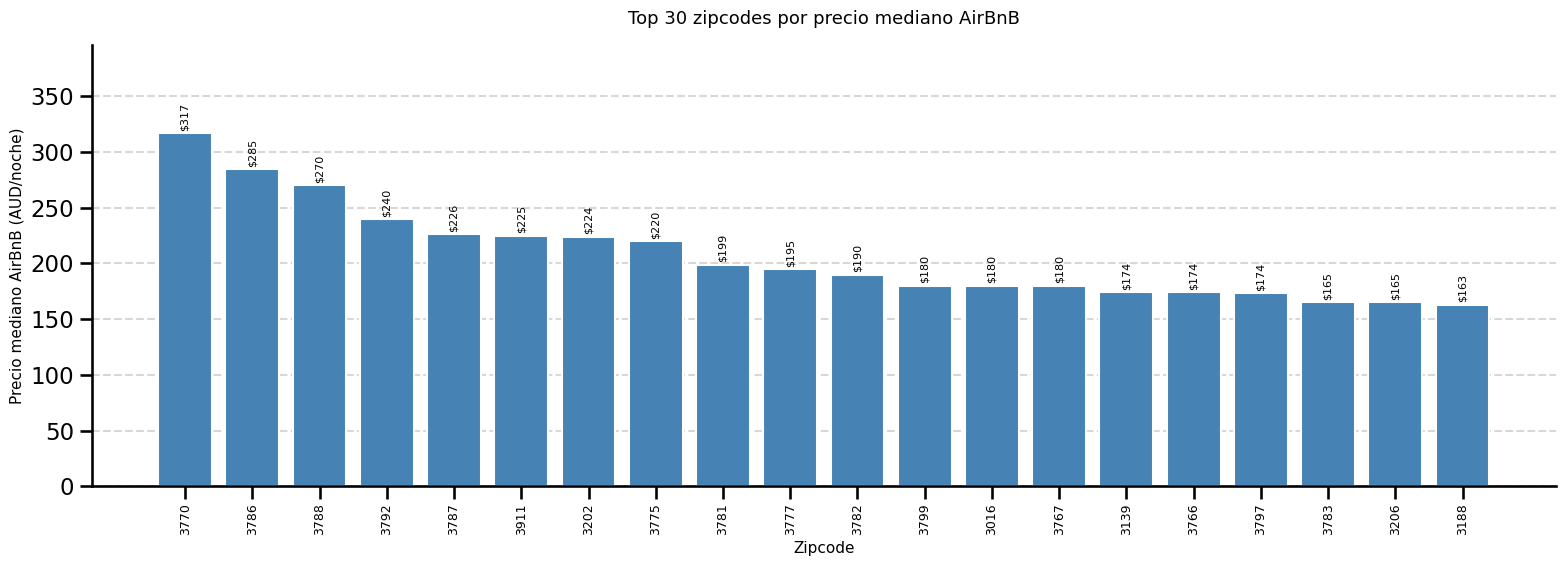

In [75]:
# Gráfico
plot_data = airbnb_filtrado.sort_values('airbnb_price_median', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(plot_data['zipcode'].astype(str),
              plot_data['airbnb_price_median'],
              color='steelblue', edgecolor='white')

for bar, precio in zip(bars, plot_data['airbnb_price_median']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'${precio:.0f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_title('Top 30 zipcodes por precio mediano AirBnB', fontsize=13, pad=15)
ax.set_ylabel('Precio mediano AirBnB (AUD/noche)', fontsize=11)
ax.set_xlabel('Zipcode', fontsize=11)
ax.set_xticks(range(len(plot_data)))
ax.set_xticklabels(plot_data['zipcode'].astype(str), rotation=90, fontsize=9)
ax.set_ylim(0, plot_data['airbnb_price_median'].max() * 1.25)  # margen dinámico
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

El gráfico muestra una caída gradual desde el zipcode 3770 (317 AUD/noche). Le sigue un segundo grupo (3786, 3788, 3792) en torno a 240-285 AUD/noche, correspondiente a zonas de alta demanda turística. A partir del zipcode 3781 la curva se aplana en el rango 163-199 AUD/noche, reflejando el mercado general de alquiler de Melbourne.

In [77]:
#Tabla
tabla = airbnb_filtrado.sort_values('airbnb_price_median', ascending=False).head(10).copy()

tabla = tabla[['zipcode', 'airbnb_price_median', 'airbnb_record_count',
               'airbnb_weekly_price_median', 'airbnb_monthly_price_median']]
tabla.columns = ['Zipcode', 'Precio mediano (AUD/noche)', 'Cantidad listings',
                 'Precio semanal mediano (AUD)', 'Precio mensual mediano (AUD)']

for col in ['Precio mediano (AUD/noche)', 'Precio semanal mediano (AUD)', 'Precio mensual mediano (AUD)']:
    tabla[col] = tabla[col].apply(lambda x: f'${x:.0f}' if pd.notna(x) else '-')

tabla = tabla.reset_index(drop=True)
display(tabla)

,Zipcode,Precio mediano (AUD/noche),Cantidad listings,Precio semanal mediano (AUD),Precio mensual mediano (AUD)
0,3770,$317,24,$1050,$3200
1,3786,$285,11,$762,$2688
2,3788,$270,89,$1712,$5748
3,3792,$240,16,$631,-
4,3787,$226,27,$990,$3150
5,3911,$225,10,$1340,$5940
6,3202,$224,14,-,-
7,3775,$220,45,$758,$2800
8,3781,$199,13,$950,$3000
9,3777,$195,187,$1000,$3585


El gráfico muestra el Top 10 zipcodes por precio mediano Airbnb, el zipcode 3770 lidera con 317 AUD/noche y solo 24 listings, lo que sugiere una zona de propiedades premium con baja oferta. El zipcode 3777 en cambio tiene el precio más bajo del top 10, 195 AUD/noche pero la mayor cantidad de listings (187), indicando una zona de alta actividad turística pero más accesible. Los guiones en precio semanal y mensual corresponden a zipcodes donde los listings no ofrecen estadías extendidas, lo que refuerza su perfil turísico de corta estadía.

### 2.10. Otras 2 variables para combinar los datasets


Se investigan otras 2 variables candidatas para combinar los datasets además de zipcode: suburb y neighborhood. Para cada una se analiza la cobertura potencial del match contra las variables de ubicación del dataset de Melbourne.

In [78]:
# Explorar columnas candidatas del dataset AirBnB
cols_ubicacion = ['neighborhood', 'suburb', 'zipcode']
print("Valores únicos por columna:")
print(airbnb_df[cols_ubicacion].nunique())

print("\nEjemplo neighborhood:")
print(airbnb_df['neighborhood'].value_counts().head(10))

print("\nEjemplo suburb:")
print(airbnb_df['suburb'].value_counts().head(10))

Valores únicos por columna:
neighborhood     59
suburb          542
zipcode         248
dtype: int64

Ejemplo neighborhood:
neighborhood
Central Business District    3726
Southbank                    1248
St Kilda                     1085
South Yarra                  1053
Brunswick                     728
Carlton                       585
Docklands                     576
Richmond                      547
Fitzroy                       381
Northcote                     309
Name: count, dtype: int64

Ejemplo suburb:
suburb
Melbourne          4274
Southbank          1236
South Yarra         883
Saint Kilda         805
Docklands           612
Richmond            570
Carlton             537
Brunswick           439
Fitzroy             378
North Melbourne     340
Name: count, dtype: int64


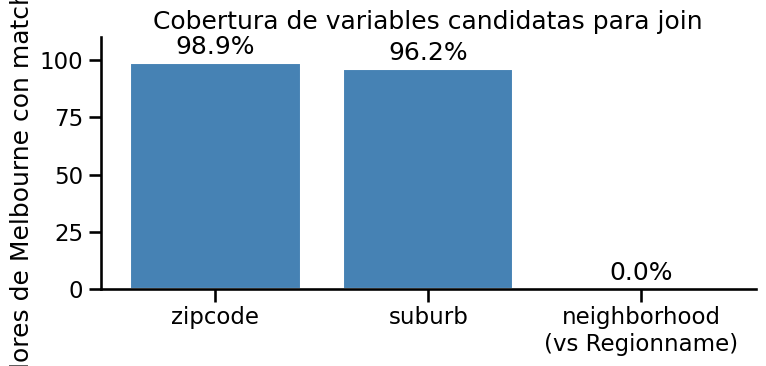

In [79]:
# Comparar cobertura de variables candidatas para join
melb_suburbs   = set(melb_ej2['Suburb'].str.lower().str.strip())
melb_zipcodes  = set(melb_ej2['Postcode'].dropna().astype(int))
melb_regions   = set(melb_ej2['Regionname'].str.lower().str.strip().dropna())

airbnb_suburbs       = set(airbnb_df['suburb'].str.lower().str.strip().dropna())
airbnb_zipcodes      = set(airbnb_df['zipcode'].dropna().astype(float).astype(int))
airbnb_neighborhoods = set(airbnb_df['neighborhood'].str.lower().str.strip().dropna())

cobertura = {
    'zipcode':                   len(melb_zipcodes & airbnb_zipcodes) / len(melb_zipcodes),
    'suburb':                    len(melb_suburbs & airbnb_suburbs) / len(melb_suburbs),
    'neighborhood\n(vs Regionname)': len(melb_regions & airbnb_neighborhoods) / len(melb_regions),
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cobertura.keys(), [v * 100 for v in cobertura.values()], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('% de valores de Melbourne con match en AirBnB')
ax.set_title('Cobertura de variables candidatas para join')
ax.set_ylim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

Se realiza el gráfico de cobertura para analizar:

**Variable zipcode** (98,9%): la variable que ya usamos. Alta cobertura y robusta porque es un código numérico estándar sin ambiguedades de nombres.

**Variable suburb** (96,2%): buena cobertura potencial, pero requiere normalización de nombres antes del join. Por ejemplo, Airbnb usa  "Saint Kilda" mientras Melbourne usa "St Kilda". Con normalización de texto básica o ayuda de un experto se pueden resolver la mayoría de los casos.Sería la mayor alternativa a zipcode por su mayor granularidad geográfica.

**Variable neighborhood** (0%): no es comparable directamente con Regionname. Airbnb usa nombres de barrios específicos ("Central Business District", "St Kilda") mientras Melbourne usa regiones administrativas amplias ("Nothern Metropolitan"). No es adecuada para un join directo sin un mapeo previo.

**Conclusión** zipcode es la variable más robusta para el join. Suburb sería una buen alternativa con normalización de nombres, y una estrategia combinada (zipcode primero, suburb como fallbac) daría la mejor cobertura posible.



**3 preguntas al experto inmobiliario:**

1.  ¿Los barrios de Airbnb ('neighborhood') tienen límites geográficos equivalentes a los 'Regionname' en el dataset de ventas, o hay zonas que quedan partidas entre dos regiones?

2. ¿Hay suburbs que hayan cambiado de nombre o se hayan fusionado con otros en los últimos años, lo que podría causar inconsistencias entre datasets de distintas fechas?

3. ¿Existe surburbs internamente  heterógenes donde no tenga sentido tratarlos como unidad para estimar precios? Por ejemplo, un suburb que mezcla zona industrial con zona residencial cara distorsionaría la mediana de preciode la zona.

### 2.11 Uso de coordenadas geoespaciales

Si las coordenadas estuvieran disponibles, se podría hacer un join con proximidad: para cada propiedad de Melbourne, tomar los n listings AirBnB más cercanos (por distancia haversine) y calcular estadísticas de precio en ese radio. Esto sería más preciso que el zipcode porque captura el entorno inmediato real de la propiedad, sin depender de los límites administrativos que puede ser heterogéneos

In [80]:
# Verificar disponibilidad de coordenadas
print(melb_ej2[['Lattitude', 'Longtitude']].notna().sum())

Lattitude     11033
Longtitude    11033
dtype: int64


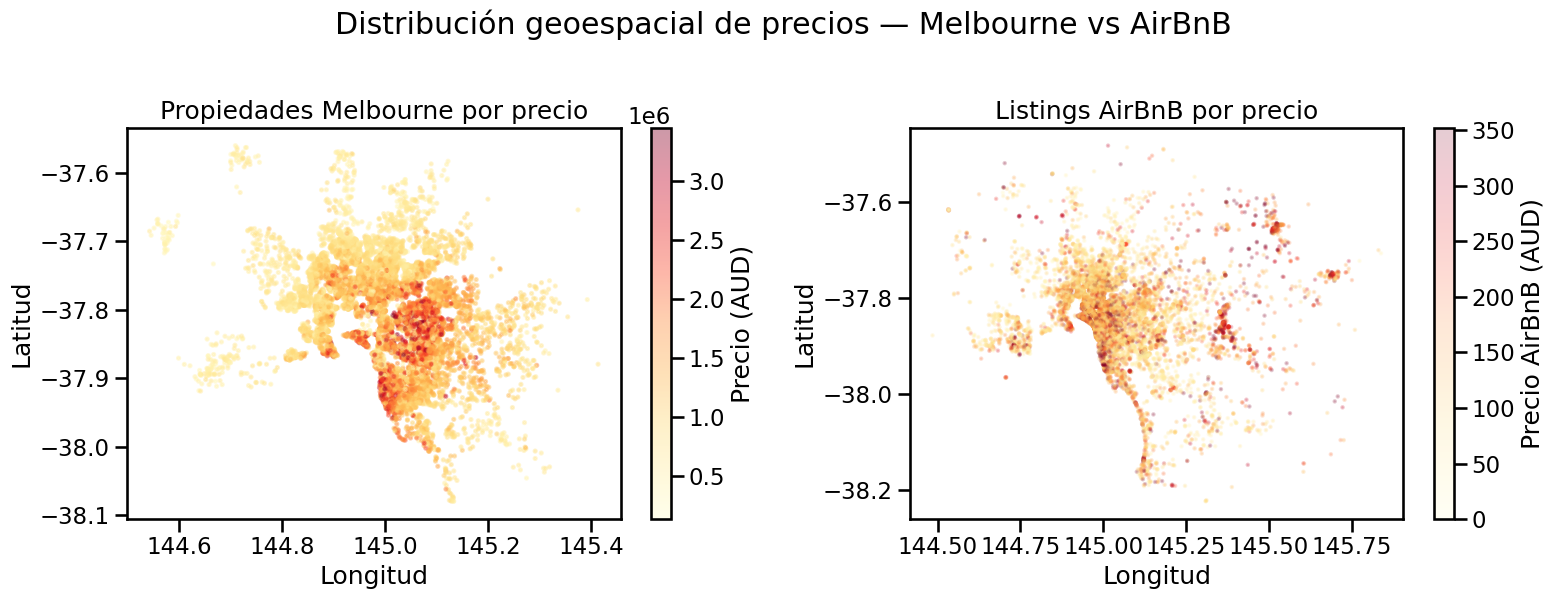

In [81]:
#Graficamos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Propiedades Melbourne coloreadas por precio
sc = axes[0].scatter(
    melb_ej2['Longtitude'], melb_ej2['Lattitude'],
    c=melb_ej2['Price'], cmap='YlOrRd', alpha=0.4, s=5
)
plt.colorbar(sc, ax=axes[0], label='Precio (AUD)')
axes[0].set_title('Propiedades Melbourne por precio')
axes[0].set_xlabel('Longitud')
axes[0].set_ylabel('Latitud')

# AirBnB listings coloreados por precio
airbnb_plot = airbnb_df[airbnb_df['latitude'].notna() & airbnb_df['longitude'].notna()].copy()
airbnb_plot['price_num'] = airbnb_plot['price']

sc2 = axes[1].scatter(
    airbnb_plot['longitude'], airbnb_plot['latitude'],
    c=airbnb_plot['price_num'], cmap='YlOrRd', alpha=0.2, s=3,
    vmax=airbnb_plot['price_num'].quantile(0.95)  # recorta outliers para mejor color
)
plt.colorbar(sc2, ax=axes[1], label='Precio AirBnB (AUD)')
axes[1].set_title('Listings AirBnB por precio')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.suptitle('Distribución geoespacial de precios — Melbourne vs AirBnB', y=1.01)
plt.tight_layout()
plt.show()

Ambos datasets cubren la misma área geográfica de Melbourne con distribuciones espaciales similares, lo que confirma que un join por coordenadas sería viable. En ambos mapas los precios más altos (tonos más oscuros) se concentran cerca del CBD (longitud 145) y la costa sur, validando que 'airbnb_price_median' y 'Price' comparten estructura espacial. Esto refuerza que las coordenadas serían una variable de join más precisa que el zipcode, ya que capturan el entorno inmediato real sin depender de límites administrativos.


**¿Qué variables adicionales mejorarían la predicción del precio?**

Variables de la propiedad:  

*   Estado de refacción / renovación: una propieda renovada vale más que una en mal estado.
*  Vista al agua o parque: diferencia propiedades de precio similar estructuralmente.
*   Propiedad con piscina o jardín propio: amenities que impactan directamente en el valor.

Variables del entorno:
*   Cercanía del transporte público (tren/ tranvía): en ciudades grandes esto impacta en el precio.
*  Calidad del colegio más cercano: clave para familias, genera sobreprecio en los zipcodes con mejores colegios.
*   Nivel de ruido del entorno: distingue zonas residenciales tranquilas de zona de alto tráfico o actividad comercial.

Variables macroeconómicas:
*   Tasas de interés al momento de la venta: el contexto crediticio directamente la demanda y los precios de mercado.
*   Historial de ventas previas de la propiedad: indica la tendencia de revalorización.

## Ejercicio 3:

Crear y guardar un nuevo conjunto de datos con todas las transformaciones realizadas anteriormente.

## Ejercicios opcionales:

El notebook `02.2 ETLs-DAGs.ipynb` tiene un esqueleto de referencia para guiarse.

1. Armar un script en python (archivo .py) [ETL](https://towardsdatascience.com/what-to-log-from-python-etl-pipelines-9e0cfe29950e) que corra los pasos de extraccion, transformacion y carga, armando una funcion para cada etapa del proceso y luego un main que corra todos los pasos requeridos.

2. Armar un DAG en Apache Airflow que corra el ETL. (https://airflow.apache.org/docs/apache-airflow/stable/tutorial.html)

3. Bonus: embeddings y búsqueda semántica con descripciones de AirBnB.
   - Usar `sentence-transformers` para codificar descripciones textuales de propiedades.
   - Tomar un subconjunto chico de descripciones, calcular embeddings y encontrar el par más similar con similitud coseno.
   - Reflexionar: ¿por qué este resultado no se puede lograr con `LIKE '%keyword%'` en SQL? ¿Qué pasa si dos propiedades son similares pero usan palabras distintas? ¿Qué representan los 384 números del embedding?

4. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?


5. Bonus: curación asistida por IA sobre `CouncilArea`.
   - Tomar los valores únicos de `CouncilArea` y pedirle a un modelo de lenguaje que sugiera posibles inconsistencias, duplicados por capitalización o spelling y agrupaciones razonables.
   - Proponer una estandarización preliminar y luego validar manualmente si el mapeo tiene sentido.
   - Reflexionar: ¿cuándo confiarías en este resultado sin revisarlo? ¿Qué pasa si el modelo inventa un mapeo incorrecto? ¿Cómo validarías el resultado si la columna tuviera miles de valores únicos?

Ejemplo conceptual:


In [ ]:
import anthropic
import json

client = anthropic.Anthropic()

# Valores únicos con posibles inconsistencias
council_values = melb_df['CouncilArea'].dropna().unique().tolist()

message = client.messages.create(
    model="claude-opus-4-7",
    max_tokens=1024,
    messages=[{
        "role": "user",
        "content": f"""Estos son los valores únicos de la columna CouncilArea en un dataset de propiedades de Melbourne:
{council_values}

Identificá: (1) duplicados con distinta capitalización o spelling,
 (2) valores que parecen errores, (3) valores que podrían agruparse.
Respondé en JSON con la estructura: {{"estandarizado": {{"valor_original": "valor_correcto"}}}}"""
    }]
)

mapping = json.loads(message.content[0].text)
melb_df['CouncilArea_clean'] = melb_df['CouncilArea'].map(
    mapping.get('estandarizado', {})
).fillna(melb_df['CouncilArea'])
